# ASSIGNMENT 2: Machine Learning
## Review Buster - NLP Classification Model
---

## *Notebook 2*

## I. K-Fold Cross Validation


**Recall from Notebook 1 — Data Exploration and Preprocessing.** We explored the 1,600 hotel reviews, removed four extra duplicate rows, and reserved all reviews from four hotels for final testing. This left 1,277 reviews from 16 hotels for training and 319 reviews from four held-out hotels. We then applied light text cleaning: lowercasing, removing HTML tags, replacing URLs, and normalising whitespace.

Notebook 1 also explored four TF-IDF representations of the review text: unigrams or unigrams plus bigrams, each with and without lemmatisation. Its vectorisers were fitted on all 16 training hotels and used to transform the held-out hotels. For cross-validation in this notebook, we return to the cleaned training text and fit a new vectoriser within each training fold. The four held-out hotels remain reserved for the final evaluation.


### 1. K-Fold Cross Validation Overview


#### Purpose of cross-validation

We use five-fold cross-validation to compare candidate text representations and model families before choosing a final prediction pipeline. For each candidate, we train and evaluate it five times, changing which group of hotels is used for validation. We then compare its performance across those runs to assess how consistently it predicts reviews from hotels it did not train on.

This helps us choose a pipeline that appears to generalise beyond particular training hotels. Cross-validation is used for model selection; the four hotels held out earlier remain untouched for the final evaluation.

#### Creating five hotel-grouped folds

The training dataframe contains reviews from 16 hotels. We divide these hotels into five non-overlapping folds: one fold contains four hotels, and the other four folds contain three hotels each. All reviews from a hotel stay in the same fold.

Five folds give each candidate five opportunities to predict reviews from unseen hotels, while retaining reviews from approximately 12–13 hotels for training in each run. We use the same fold assignments for every candidate so their results are directly comparable. We will also check the number of reviews and truthful/deceptive labels in each fold.

#### The five runs

| Run | Training data | Validation data |
|---|---|---|
| 1 | Folds 2–5 | Fold 1 |
| 2 | Folds 1, 3–5 | Fold 2 |
| 3 | Folds 1–2, 4–5 | Fold 3 |
| 4 | Folds 1–3, 5 | Fold 4 |
| 5 | Folds 1–4 | Fold 5 |

After five runs, every training review has been used for validation once. We can summarise each candidate's five validation scores using their mean and variation across folds.


#### Preparing inputs within each run

We start with the light-cleaned review text, its `deceptive` label, and its `hotel` name for grouping. We do not use the TF-IDF tables already fitted on all 16 training hotels for cross-validation.

Within each run, we create the selected text representation as follows:

1. Fit a new TF-IDF vectoriser only on the four training folds. It learns its vocabulary and IDF weights from those reviews.
2. Transform the four training folds and fit the candidate classifier.
3. Use that same fitted vectoriser to transform the remaining validation fold, then score the classifier's predictions.
4. Repeat with a newly fitted vectoriser when the validation fold changes.

This ensures that the validation fold does not influence the vocabulary, IDF weights, or classifier training. The same procedure applies to each representation and model candidate. Once cross-validation has identified the preferred pipeline, we will fit it on all 16 training hotels and evaluate it once on the four hotels reserved for final testing.


### 2. Preparing for the K-Fold CV


#### 2.1) Folds for No Lemmatisation

We first load the lightly cleaned training dataframe without lemmatisation. It contains 1,277 reviews from 16 hotels. We use `hotel` only to create five grouped splits, keeping every review from the same hotel together. After the split indices are known, each **no-lemma fold dataframe** keeps just `text` and `deceptive`. We leave out `hotel`, `source`, and `polarity` because they are not prediction inputs; `deceptive` is the target, not an input feature.

The fold numbers are dictionary keys (`no_lemma_folds[1]` through `no_lemma_folds[5]`). The code shows each fold's hotel and label counts, checks that a run's training and validation hotels never overlap, and previews Fold 1. No TF-IDF vectoriser is fitted in this preparation step.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display
from sklearn.model_selection import GroupKFold

no_lemma_training_df = pd.read_pickle(
    Path("data/lightly_cleaned_training_df.pkl.gz")
).reset_index(drop=True)

assert len(no_lemma_training_df) == 1277
assert no_lemma_training_df["hotel"].nunique() == 16
assert no_lemma_training_df[["text", "deceptive", "hotel"]].notna().all().all()

# Hotel names determine the split, but are not included in the fold dataframes.
cv = GroupKFold(n_splits=5)
hotel_fold_splits = list(
    cv.split(
        X=no_lemma_training_df["text"],
        y=no_lemma_training_df["deceptive"],
        groups=no_lemma_training_df["hotel"],
    )
)

no_lemma_model_df = no_lemma_training_df[["text", "deceptive"]].copy()
no_lemma_folds = {}
no_lemma_fold_summary = []

for fold_number, (train_idx, validation_idx) in enumerate(hotel_fold_splits, start=1):
    training_hotels = set(no_lemma_training_df.iloc[train_idx]["hotel"])
    validation_hotels = set(no_lemma_training_df.iloc[validation_idx]["hotel"])
    assert training_hotels.isdisjoint(validation_hotels)

    fold_df = no_lemma_model_df.iloc[validation_idx].copy()
    no_lemma_folds[fold_number] = fold_df
    no_lemma_fold_summary.append({
        "Fold": fold_number,
        "Validation hotels": ", ".join(sorted(validation_hotels)),
        "Reviews": len(fold_df),
        "Truthful": int((fold_df["deceptive"] == 0).sum()),
        "Deceptive": int((fold_df["deceptive"] == 1).sum()),
    })

assert len(no_lemma_folds) == 5
assert set().union(*(set(df.index) for df in no_lemma_folds.values())) == set(no_lemma_model_df.index)
assert sum(len(df) for df in no_lemma_folds.values()) == len(no_lemma_model_df)
assert all(list(df.columns) == ["text", "deceptive"] for df in no_lemma_folds.values())

display(pd.DataFrame(no_lemma_fold_summary))
print("First five rows of Fold 1 — no lemmatisation:")
with pd.option_context("display.max_colwidth", 95):
    display(no_lemma_folds[1].head())

,Fold,Validation hotels,Reviews,Truthful,Deceptive
0,1,"fairmont, james, talbott",240,120,120
1,2,"conrad, intercontinental, swissotel",240,120,120
2,3,"ambassador, hyatt, sofitel",240,120,120
3,4,"amalfi, hilton, sheraton",240,120,120
4,5,"affinia, hardrock, omni, palmer",317,157,160


First five rows of Fold 1 — no lemmatisation:


,text,deceptive
10,i stayed at the fairmont chicago for one night - i'm a frequent business traveler and am ve...,0
20,i stayed at the fairmont for a few nights and found the whole experience excellent. i was g...,0
21,we went to chicago to see an exhibit at the art institute and selected the fairmont because...,0
22,i actually booked this reservation with the hotel over the phone and got a great rate -- mu...,0
26,"simply a nice place to stay... i had a great deal for the room, and was impressed with the ...",0


#### 2.2) Folds for Lemmatisation

We next load the lemmatised version of the same training reviews. This file already contains lemmatised `text`, so we do not repeat lemmatisation here. We verify that its rows, labels, and hotel metadata align with the no-lemma dataframe, then apply the **same five split indices**. Thus, Fold 1 in `lemma_folds` contains exactly the same reviews and hotels as Fold 1 in `no_lemma_folds`; only the text representation differs.

Each lemmatised fold dataframe again keeps only `text` and `deceptive`. We use `hotel` to verify the allocation, then leave it, `source`, and `polarity` out of the fold dataframes. TF-IDF will be fitted separately within each later cross-validation training run.

In [2]:
lemma_training_df = pd.read_pickle(
    Path("data/lightly_cleaned_lemmatised_training_df.pkl.gz")
).reset_index(drop=True)

# Reusing indices is valid only when both files contain the same reviews in the same order.
assert len(lemma_training_df) == len(no_lemma_training_df)
for column in ["deceptive", "hotel", "polarity", "source"]:
    assert lemma_training_df[column].equals(no_lemma_training_df[column])
assert lemma_training_df["text"].notna().all()

lemma_model_df = lemma_training_df[["text", "deceptive"]].copy()
lemma_folds = {}
lemma_fold_summary = []

for fold_number, (train_idx, validation_idx) in enumerate(hotel_fold_splits, start=1):
    training_hotels = set(lemma_training_df.iloc[train_idx]["hotel"])
    validation_hotels = set(lemma_training_df.iloc[validation_idx]["hotel"])
    assert training_hotels.isdisjoint(validation_hotels)

    fold_df = lemma_model_df.iloc[validation_idx].copy()
    lemma_folds[fold_number] = fold_df
    lemma_fold_summary.append({
        "Fold": fold_number,
        "Validation hotels": ", ".join(sorted(validation_hotels)),
        "Reviews": len(fold_df),
        "Truthful": int((fold_df["deceptive"] == 0).sum()),
        "Deceptive": int((fold_df["deceptive"] == 1).sum()),
    })

assert len(lemma_folds) == 5
assert set().union(*(set(df.index) for df in lemma_folds.values())) == set(lemma_model_df.index)
assert sum(len(df) for df in lemma_folds.values()) == len(lemma_model_df)
assert all(list(df.columns) == ["text", "deceptive"] for df in lemma_folds.values())
assert pd.DataFrame(lemma_fold_summary).equals(pd.DataFrame(no_lemma_fold_summary))

display(pd.DataFrame(lemma_fold_summary))
print("First five rows of Fold 1 — lemmatisation:")
with pd.option_context("display.max_colwidth", 95):
    display(lemma_folds[1].head())

,Fold,Validation hotels,Reviews,Truthful,Deceptive
0,1,"fairmont, james, talbott",240,120,120
1,2,"conrad, intercontinental, swissotel",240,120,120
2,3,"ambassador, hyatt, sofitel",240,120,120
3,4,"amalfi, hilton, sheraton",240,120,120
4,5,"affinia, hardrock, omni, palmer",317,157,160


First five rows of Fold 1 — lemmatisation:


,text,deceptive
10,i stay at the fairmont chicago for one night - i'm a frequent business traveler and be very...,0
20,i stay at the fairmont for a few night and find the whole experience excellent. i be give a...,0
21,we go to chicago to see an exhibit at the art institute and select the fairmont because it ...,0
22,i actually book this reservation with the hotel over the phone and get a great rate -- much...,0
26,"simply a nice place to stay... i have a great deal for the room, and be impress with the qu...",0


### 3. Implement K-Fold CV on Non-Lemmatised Data Frames

#### 3.1) Logistic Regression on Non-Lemmatised Reviews

##### 3.1.1) Baseline trial (`C=1.0`)

**Two text representations**

We perform five-fold cross-validation on the hotel-grouped splits prepared in Section 2. Logistic regression will be evaluated twice at the starting `C=1.0` on the **same five splits**:

- **Unigrams:** each word is a separate TF-IDF feature.
- **Unigrams + bigrams:** individual words remain features, and adjacent two-word phrases become additional features. This is not a bigram-only model.

This comparison asks whether short phrases add useful information when predicting reviews from hotels absent from a run's training folds. Phrases can express context that isolated words miss, but the larger vocabulary can also fit wording specific to the training reviews. We will judge the trade-off from cross-validation results.

In [3]:
# Each value specifies the smallest and largest word n-gram to extract.
representations = {
    "unigrams": (1, 1),
    "unigrams + bigrams": (1, 2),
}

**The evaluation function**

Section 2 assigned reviews to hotel-grouped folds but left their text unvectorised. The function below creates a **new pipeline in every run**. Its first step learns TF-IDF features from the four training folds; its second step fits logistic regression using those features. The fitted pipeline then transforms and predicts the remaining fold. Keeping these steps together prevents the validation fold from influencing the vocabulary, IDF weights, or model training. The function accepts `C`, with `1.0` as its default for the baseline runs below. See the [scikit-learn Pipeline documentation](https://scikit-learn.org/1.6/modules/generated/sklearn.pipeline.Pipeline.html).

In [4]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


def evaluate_logistic_regression(representation_name, ngram_range, C=1.0):
    fold_results = []

    # Reuse the five hotel-grouped runs prepared in Section 2.
    for fold_number, (train_idx, val_idx) in enumerate(
        hotel_fold_splits, start=1
    ):
        train = no_lemma_model_df.iloc[train_idx]
        validation = no_lemma_model_df.iloc[val_idx]

        # A new pipeline learns a new vocabulary, IDF weights, and model.
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=ngram_range,
                min_df=2,
                stop_words=None,
                token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
                lowercase=False,
                smooth_idf=True,
                norm="l2",
            )),
            ("model", LogisticRegression(
                penalty="l2",
                C=C,
                solver="liblinear",
                fit_intercept=True,
                class_weight=None,
                max_iter=1000,
                random_state=42,
            )),
        ])

        # Fit TF-IDF on the training text, then learn classifier weights.
        pipeline.fit(train["text"], train["deceptive"])

        # Transform and predict the held-out fold without fitting on it.
        predictions = pipeline.predict(validation["text"])

        fold_results.append({
            "Representation": representation_name,
            "C": C,
            "Fold": fold_number,
            "Training reviews": len(train),
            "Validation reviews": len(validation),
            "TF-IDF features": len(
                pipeline.named_steps["tfidf"].get_feature_names_out()
            ),
            "Accuracy": accuracy_score(
                validation["deceptive"], predictions
            ),
            "Precision": precision_score(
                validation["deceptive"], predictions
            ),
            "Recall": recall_score(
                validation["deceptive"], predictions
            ),
            "Deceptive F1": f1_score(
                validation["deceptive"], predictions
            ),
            "Macro F1": f1_score(
                validation["deceptive"], predictions,
                average="macro",
            ),
        })

    # One result row per validation run: five rows per representation.
    return pd.DataFrame(fold_results)

**Why these TF-IDF settings?**

| Setting | Reason |
|---|---|
| `ngram_range` | The experimental variable: `(1, 1)` tests individual words; `(1, 2)` tests words plus adjacent phrases. |
| `min_df=2` | A term must appear in at least two reviews **within that run's training folds**. This limits one-off terms and matches Notebook 1's starting choice. It could also remove a rare useful term, so it may be tuned later. |
| `stop_words=None` | Keeps negations, pronouns, and other common words that may convey meaning or writing style. |
| `token_pattern=...` | Keeps one-character tokens and contractions, matching Notebook 1's tokenisation. |
| `lowercase=False` | The saved training text was already lowercased during light cleaning. |
| `smooth_idf=True` | Uses smoothed document frequencies, softening the relative weight of very rare terms. |
| `norm="l2"` | Scales each review's TF-IDF vector to unit length, limiting the effect of review length on vector magnitude. |

All other vectoriser choices remain fixed while we compare n-gram ranges. **TF-IDF's `norm="l2"` and the classifier's L2 penalty are different operations**: the former scales each review vector; the latter constrains learned model weights. See the [scikit-learn TfidfVectorizer documentation](https://scikit-learn.org/1.6/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).

**Why these logistic regression settings?**

Logistic regression learns feature weights \(w\) and an intercept \(b\). For a review vector \(x\), it computes \(z = w^\top x + b\), then maps that score through the sigmoid function to estimate the probability of class `1` (deceptive). Its solver learns the weights by minimising log loss with regularisation.

| Setting | Reason |
|---|---|
| `penalty="l2"` | Shrinks large weights while allowing many words to contribute. With thousands of text features and 1,277 training reviews, this is a sensible starting constraint when the goal is prediction on unseen hotels. L1 would set some weights exactly to zero; that may be useful later, but has not yet been shown to help here. |
| `C` (default `1.0`) | The default is a starting regularisation strength, **not an optimal value established by evidence**. Smaller `C` means stronger regularisation; we can pass other values to the same function in later tuning. |
| `solver="liblinear"` | A numerical solver suitable for this binary, L2-regularised model with sparse TF-IDF inputs. It optimises the weights and intercept for us. |
| `fit_intercept=True` | Learns the intercept \(b\), allowing a baseline score as well as contributions from word features. |
| `class_weight=None` | Keeps the observed training distribution. The two labels are nearly balanced, so weighting one class more has no current justification. |
| `max_iter=1000` | Gives the solver room to converge. We should still check for convergence warnings; this setting does not change the model's hypothesis space. |
| `random_state=42` | Makes solver behaviour reproducible where randomness is involved. |

L2 is a reasoned starting choice rather than a proven winner. Log loss learns the weights *within a run*; validation metrics assess how well those weights predict held-out hotels. See the [scikit-learn LogisticRegression documentation](https://scikit-learn.org/1.6/modules/generated/sklearn.linear_model.LogisticRegression.html).

**What `fit()` and `predict()` do**

`pipeline.fit(train["text"], train["deceptive"])` receives the four training folds' cleaned review strings as inputs and their `0`/`1` labels as targets. It fits the TF-IDF vocabulary and IDF weights on **those strings only**, transforms them into vectors, and fits logistic regression's weights and intercept to those vectors and labels.

`pipeline.predict(validation["text"])` receives only the fifth fold's review strings. It uses the **existing** vocabulary and IDF weights to transform them, then returns predicted labels without updating either pipeline component. For logistic regression, the default class decision corresponds to a probability threshold of 0.5 for class `1`.

**Function output**

For **one representation**, `evaluate_logistic_regression(...)` returns a dataframe with **five rows**, one per fold. Each row records the representation, `C` value, fold number, training and validation sizes, number of TF-IDF features learned in that run, and validation metrics. The function reports results; it does **not** combine the five fitted weight vectors into one model. The next part of this section will call the function for both representations and compare its results.

**Running the five-fold comparison**

We now run the evaluation function once for unigrams and once for unigrams plus bigrams, using its default `C=1.0`. Both use the same five hotel-grouped runs. For each run, we will show the four folds used for training, the held-out validation fold, and its results. We will then compare mean scores and their variation across folds. The four hotels reserved for final testing are not used here.

In [5]:
# Run five hotel-grouped validations for each representation at default C=1.0.
logistic_fold_results = pd.concat(
    [
        evaluate_logistic_regression(name, ngram_range)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the fold combination and hotel names for readable result tables.
logistic_fold_results["Training folds"] = logistic_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
logistic_fold_results["Validation fold"] = logistic_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
validation_hotels_by_fold = {
    row["Fold"]: row["Validation hotels"]
    for row in no_lemma_fold_summary
}
logistic_fold_results["Validation hotels"] = logistic_fold_results["Fold"].map(
    validation_hotels_by_fold
)

assert len(logistic_fold_results) == 10
assert logistic_fold_results.groupby("Representation")["Validation reviews"].sum().eq(1277).all()

**Individual fold results**

In [6]:
# Show Fold 1 through Fold 5 separately for each representation.
fold_result_columns = [
    "Fold", "C", "Training folds", "Validation fold", "Validation hotels",
    "Training reviews", "Validation reviews", "TF-IDF features",
    "Accuracy", "Precision", "Recall", "Deceptive F1", "Macro F1",
]

for representation_name in representations:
    print(f"Logistic regression — {representation_name}")
    representation_results = logistic_fold_results.loc[
        logistic_fold_results["Representation"] == representation_name,
        fold_result_columns,
    ].set_index("Fold")
    display(representation_results.round(3))

Logistic regression — unigrams


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,4168,0.846,0.827,0.875,0.850,0.846
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,4290,0.846,0.855,0.833,0.844,0.846
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,4268,0.788,0.835,0.717,0.771,0.786
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,4264,0.846,0.832,0.867,0.849,0.846
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,4102,0.871,0.905,0.831,0.866,0.871


Logistic regression — unigrams + bigrams


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,19671,0.854,0.815,0.917,0.863,0.854
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,20164,0.850,0.850,0.850,0.850,0.850
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,20045,0.817,0.865,0.750,0.804,0.816
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,20075,0.850,0.844,0.858,0.851,0.850
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,18818,0.883,0.902,0.862,0.882,0.883


**Summary comparison**

In [7]:
# Compare each metric's mean and sample standard deviation across five folds.
comparison_metrics = [
    "Accuracy", "Precision", "Recall", "Deceptive F1", "Macro F1"
]
logistic_cv_summary = (
    logistic_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)
display(logistic_cv_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.839               0.851
             std      0.031               0.024
Precision    mean     0.851               0.855
             std      0.032               0.032
Recall       mean     0.825               0.847
             std      0.063               0.060
Deceptive F1 mean     0.836               0.850
             std      0.037               0.029
Macro F1     mean     0.839               0.851
             std      0.031               0.024

##### 3.1.2) Trial: stronger L2 regularisation (`C=0.1`)

We now repeat the **same five hotel-grouped validation runs** for both non-lemmatised representations, changing only logistic regression's `C` from `1.0` to `0.1`. A smaller `C` applies stronger L2 regularisation. The folds and TF-IDF settings remain unchanged.

In [8]:
# Reuse the existing evaluation function and both representations.
logistic_c01_results = pd.concat(
    [
        evaluate_logistic_regression(name, ngram_range, C=0.1)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the same fold descriptions used in the C=1.0 result tables.
logistic_c01_results["Training folds"] = logistic_c01_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
logistic_c01_results["Validation fold"] = logistic_c01_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
logistic_c01_results["Validation hotels"] = logistic_c01_results["Fold"].map(
    validation_hotels_by_fold
)

assert len(logistic_c01_results) == 10
assert logistic_c01_results["C"].eq(0.1).all()
assert logistic_c01_results.groupby("Representation")["Validation reviews"].sum().eq(1277).all()

**Individual fold results at `C=0.1`**

In [9]:
for representation_name in representations:
    print(f"Logistic regression — {representation_name}, C=0.1")
    display(
        logistic_c01_results.loc[
            logistic_c01_results["Representation"] == representation_name,
            [
                "Fold", "Training folds", "Validation fold",
                "Validation hotels", "Accuracy", "Precision",
                "Recall", "Deceptive F1", "Macro F1",
            ],
        ].set_index("Fold").round(3)
    )

Logistic regression — unigrams, C=0.1


,Training folds,Validation fold,Validation hotels,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,
1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",0.812,0.782,0.867,0.822,0.812
2,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",0.804,0.807,0.800,0.803,0.804
3,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",0.779,0.819,0.717,0.764,0.778
4,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",0.796,0.780,0.825,0.802,0.796
5,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",0.817,0.849,0.775,0.810,0.817


Logistic regression — unigrams + bigrams, C=0.1


,Training folds,Validation fold,Validation hotels,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,
1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",0.821,0.781,0.892,0.833,0.820
2,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",0.825,0.820,0.833,0.826,0.825
3,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",0.792,0.843,0.717,0.775,0.790
4,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",0.821,0.813,0.833,0.823,0.821
5,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",0.839,0.876,0.794,0.833,0.839


**Validation metric summary at `C=0.1`**

In [10]:
# Summarise each validation metric across the five folds for each representation.
logistic_c01_summary = (
    logistic_c01_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)
display(logistic_c01_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.802               0.819
             std      0.015               0.017
Precision    mean     0.807               0.827
             std      0.029               0.035
Recall       mean     0.797               0.814
             std      0.056               0.065
Deceptive F1 mean     0.800               0.818
             std      0.022               0.024
Macro F1     mean     0.801               0.819
             std      0.015               0.018

##### 3.1.3) Trial: weaker L2 regularisation (`C=10`)

We repeat the same five hotel-grouped validation runs for both non-lemmatised text representations with `C=10`. A larger `C` applies weaker L2 regularisation. The folds and TF-IDF settings stay the same.

In [11]:
# Run both representations on the same five folds.
logistic_c10_results = pd.concat(
    [
        evaluate_logistic_regression(name, ngram_range, C=10)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add fold details for the result tables.
logistic_c10_results["Training folds"] = logistic_c10_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
logistic_c10_results["Validation fold"] = logistic_c10_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
logistic_c10_results["Validation hotels"] = logistic_c10_results["Fold"].map(
    validation_hotels_by_fold
)

assert len(logistic_c10_results) == 10
assert logistic_c10_results["C"].eq(10).all()
assert logistic_c10_results.groupby("Representation")["Validation reviews"].sum().eq(1277).all()

**Individual fold results at `C=10`**

In [12]:
for representation_name in representations:
    print(f"Logistic regression — {representation_name}, C=10")
    display(
        logistic_c10_results.loc[
            logistic_c10_results["Representation"] == representation_name,
            [
                "Fold", "Training folds", "Validation fold",
                "Validation hotels", "Accuracy", "Precision",
                "Recall", "Deceptive F1", "Macro F1",
            ],
        ].set_index("Fold").round(3)
    )

Logistic regression — unigrams, C=10


,Training folds,Validation fold,Validation hotels,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,
1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",0.879,0.870,0.892,0.881,0.879
2,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",0.871,0.880,0.858,0.869,0.871
3,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",0.804,0.854,0.733,0.789,0.803
4,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",0.854,0.851,0.858,0.855,0.854
5,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",0.893,0.932,0.850,0.889,0.893


Logistic regression — unigrams + bigrams, C=10


,Training folds,Validation fold,Validation hotels,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,
1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",0.879,0.847,0.925,0.884,0.879
2,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",0.883,0.904,0.858,0.880,0.883
3,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",0.833,0.877,0.775,0.823,0.833
4,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",0.883,0.883,0.883,0.883,0.883
5,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",0.915,0.929,0.900,0.914,0.915


**Validation metric summary at `C=10`**

In [13]:
# Show the mean and standard deviation across five folds.
logistic_c10_summary = (
    logistic_c10_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)
display(logistic_c10_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.860               0.879
             std      0.034               0.029
Precision    mean     0.877               0.888
             std      0.032               0.030
Recall       mean     0.838               0.868
             std      0.061               0.058
Deceptive F1 mean     0.857               0.877
             std      0.040               0.033
Macro F1     mean     0.860               0.879
             std      0.035               0.029

##### 3.1.4) Comparison of Logistic Regression Regularisation Settings

The tables below compare `C=0.1`, `C=1`, and `C=10` separately for each non-lemmatised text representation. Each entry shows the **mean ± sample standard deviation** of a validation metric across the same five hotel-grouped folds. The unigrams + bigrams representation includes both one-word and two-word terms.

In [14]:
# Combine the existing per-fold results for all three C settings.
logistic_c_results = pd.concat(
    [logistic_c01_results, logistic_fold_results, logistic_c10_results],
    ignore_index=True,
)


def c_comparison_table(representation_name):
    # Compute mean and sample standard deviation across the five folds.
    summary = (
        logistic_c_results.loc[
            logistic_c_results["Representation"] == representation_name
        ]
        .groupby("C")[comparison_metrics]
        .agg(["mean", "std"])
        .sort_index()
    )

    # Put the mean and standard deviation together for a compact comparison.
    return pd.DataFrame({
        metric: (
            summary[(metric, "mean")].map("{:.3f}".format)
            + " ± "
            + summary[(metric, "std")].map("{:.3f}".format)
        )
        for metric in comparison_metrics
    }).rename_axis("C")


print("Unigrams")
display(c_comparison_table("unigrams"))

print("Unigrams + bigrams")
display(c_comparison_table("unigrams + bigrams"))

Unigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
0.1,0.802 ± 0.015,0.807 ± 0.029,0.797 ± 0.056,0.800 ± 0.022,0.801 ± 0.015
1.0,0.839 ± 0.031,0.851 ± 0.032,0.825 ± 0.063,0.836 ± 0.037,0.839 ± 0.031
10.0,0.860 ± 0.034,0.877 ± 0.032,0.838 ± 0.061,0.857 ± 0.040,0.860 ± 0.035


Unigrams + bigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
0.1,0.819 ± 0.017,0.827 ± 0.035,0.814 ± 0.065,0.818 ± 0.024,0.819 ± 0.018
1.0,0.851 ± 0.024,0.855 ± 0.032,0.847 ± 0.060,0.850 ± 0.029,0.851 ± 0.024
10.0,0.879 ± 0.029,0.888 ± 0.030,0.868 ± 0.058,0.877 ± 0.033,0.879 ± 0.029


**Observations from Logistic Regression Cross-Validation**

Logistic regression performed well on the hotels held out during each validation run. Its highest mean deceptive F1 was **0.877**, using unigrams + bigrams at `C=10`; that configuration also reached a mean macro F1 of **0.879**. Most mean metrics exceeded 0.80. The exception was unigram recall at `C=0.1`, which was 0.797.

Adding bigrams improved the **five-fold mean of every reported metric** at each of the three `C` settings. For example, at `C=10`, mean macro F1 rose from 0.860 with unigrams to 0.879 with unigrams + bigrams. This pattern holds for the averages, although the combined representation did not score higher on every metric in every individual fold.

Mean performance increased as `C` rose from `0.1` to `1` to `10`. Because a larger `C` weakens L2 regularisation, these results suggest that the stronger penalty at `C=0.1` constrained these models too much. `C=10` is the best value **among those tested**; the results do not show whether a larger value would help.

**Fold 3 produced the lowest macro F1 in all six combinations** of representation and `C`. At `C=10`, its macro F1 was 0.803 for unigrams, compared with 0.854–0.893 in the other folds; with unigrams + bigrams it was 0.833, compared with 0.879–0.915. Deceptive-class recall was also notably lower in Fold 3: 0.733 for unigrams and 0.775 for unigrams + bigrams at `C=10`. This means the models missed more deceptive reviews in that fold. Fold 3 contains reviews from the ambassador, hyatt, and sofitel hotels, but these results alone do not establish *why* those reviews were harder to classify.

Overall, `C=10` with unigrams + bigrams is the strongest logistic regression configuration tested here. The next model-family comparison can use these hotel-grouped validation results before any final held-out test evaluation.

#### 3.2) SVM on Non-Lemmatised Reviews

##### 3.2.1) Baseline trial (`C=1.0`)

Support vector machines can use a linear decision boundary or a kernel that allows a nonlinear boundary. For the sparse TF-IDF features in this project, we will evaluate scikit-learn's `LinearSVC` first.

**Why use `LinearSVC`?**

We will evaluate a **linear support vector classifier** on the same non-lemmatised reviews and hotel-grouped folds used for logistic regression. After TF-IDF converts each review into a feature vector, `LinearSVC` learns a linear boundary between genuine and deceptive reviews. It balances a wide separation margin against errors and margin violations.

TF-IDF produces thousands of mostly empty features, and `LinearSVC` accepts sparse input. It also gives us a different learning objective to compare with logistic regression while the text representation and validation folds stay the same. Our goal is to see which approach predicts reviews from **unseen hotels** more reliably. `LinearSVC` does not provide probabilities by default, but it predicts the class labels needed for our current metrics. See the [scikit-learn LinearSVC documentation](https://scikit-learn.org/1.6/modules/generated/sklearn.svm.LinearSVC.html).

**The SVM evaluation function**

As in Section 3.1, the function below creates a **new pipeline for each hotel-grouped validation run**. Its TF-IDF vectoriser learns a vocabulary and IDF weights from the four training folds, then its SVM learns a decision boundary from those transformed reviews and their labels. The pipeline transforms and predicts the fifth fold without fitting on it. The function accepts `C`, with `1.0` as its initial value.

In [15]:
from sklearn.svm import LinearSVC


def evaluate_linear_svm(representation_name, ngram_range, C=1.0):
    fold_results = []

    # Reuse the five hotel-grouped splits prepared in Section 2.
    for fold_number, (train_idx, val_idx) in enumerate(
        hotel_fold_splits, start=1
    ):
        train = no_lemma_model_df.iloc[train_idx]
        validation = no_lemma_model_df.iloc[val_idx]

        # Create a fresh vectoriser and SVM for this validation run.
        # Both components will be fitted on the four training folds only.
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=ngram_range,
                min_df=2,
                stop_words=None,
                token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
                lowercase=False,
                smooth_idf=True,
                norm="l2",
            )),
            ("model", LinearSVC(
                penalty="l2",
                loss="squared_hinge",
                dual="auto",
                C=C,
                fit_intercept=True,
                class_weight=None,
                random_state=42,
                max_iter=5000,
            )),
        ])

        # Learn the vocabulary, IDF weights, and SVM boundary from training.
        pipeline.fit(train["text"], train["deceptive"])

        # Transform and predict the held-out fold without refitting.
        predictions = pipeline.predict(validation["text"])

        # Record this fold's validation results; class 1 is deceptive.
        fold_results.append({
            "Representation": representation_name,
            "C": C,
            "Fold": fold_number,
            "Training reviews": len(train),
            "Validation reviews": len(validation),
            "TF-IDF features": len(
                pipeline.named_steps["tfidf"].get_feature_names_out()
            ),
            "Accuracy": accuracy_score(
                validation["deceptive"], predictions
            ),
            "Precision": precision_score(
                validation["deceptive"], predictions
            ),
            "Recall": recall_score(
                validation["deceptive"], predictions
            ),
            "Deceptive F1": f1_score(
                validation["deceptive"], predictions
            ),
            "Macro F1": f1_score(
                validation["deceptive"], predictions,
                average="macro",
            ),
        })

    # Return one row per held-out validation fold.
    return pd.DataFrame(fold_results)

**Why keep these TF-IDF settings?**

Keeping the settings from Section 3.1 lets us compare classifiers using the same feature-building procedure. `ngram_range` remains the text-representation choice; all other vectoriser settings stay fixed.

| Setting | Reason |
|---|---|
| `ngram_range` | Tests unigrams `(1, 1)` and unigrams plus bigrams `(1, 2)`. |
| `min_df=2` | Keeps a term only when it appears in at least **two training reviews in that run**. This can remove one-off typos and unusual wording. It may also remove a hotel name mentioned in only one review, but it is **not a hotel-name filter**: names appearing in multiple training reviews can remain. |
| `stop_words=None` | Retains common words, including pronouns and negations, that may convey review content or writing style. |
| `token_pattern=...` | Keeps one-character words and contractions, matching the earlier tokenisation. |
| `lowercase=False` | The lightly cleaned review text has already been lowercased. |
| `smooth_idf=True` | Smooths document frequencies, reducing the extremity of weights assigned to very rare terms. |
| `norm="l2"` | Scales each review's TF-IDF vector to unit length, reducing the effect of review length on vector magnitude. |

The vectoriser is **fitted afresh on the four training folds** in each run. The held-out fold does not influence its vocabulary or IDF weights. See the [scikit-learn TfidfVectorizer documentation](https://scikit-learn.org/1.6/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).

**Why these SVM settings?**

`LinearSVC` assigns weights to TF-IDF features and adds an intercept to compute a score for each review. The score's side of the learned boundary determines the predicted class. Training balances the size of the weights against penalties for reviews within the margin or on the wrong side of the boundary. See the [scikit-learn SVM guide](https://scikit-learn.org/1.6/modules/svm.html).

| Setting | Reason |
|---|---|
| `penalty="l2"` | L2 regularisation penalises large model weights. It discourages reliance on a few features while allowing many words to contribute. This acts on the **model weights**; TF-IDF's `norm="l2"` acts on **review vectors**. |
| `loss="squared_hinge"` | Reviews correctly classified beyond the margin receive no loss. Margin violations incur a squared penalty, giving larger violations more weight. It is `LinearSVC`'s default and stays fixed for these initial trials. This choice can be more sensitive to unusual or mislabelled reviews than ordinary hinge loss. |
| `C` (initially `1.0`) | Controls the balance between regularisation and margin violations. Smaller `C` means stronger regularisation. The same function will also accept `0.1` and `10` for later trials. |
| `dual="auto"` | Lets scikit-learn choose the optimisation formulation based on the number of samples and features and the chosen penalty and loss. It affects how the model is fitted, not the text representation. |
| `fit_intercept=True` | Learns a baseline term in addition to the word-feature weights. |
| `class_weight=None` | Gives the classes equal weight, consistent with the approximately balanced training labels and the logistic regression runs. |
| `random_state=42` | Makes fitting reproducible when the chosen solver uses randomness. |
| `max_iter=5000` | Allows more iterations for convergence; convergence warnings should still be checked when the trials are run. |

For one representation and one `C` value, `evaluate_linear_svm(...)` returns **five rows**, one for each held-out fold. Each run fits a separate vectoriser and SVM; the five models are not combined into a final classifier.

**Running five-fold SVM validation at `C=1.0`**

We now run the SVM evaluation function for unigrams and unigrams plus bigrams, using the same five hotel-grouped folds. In each run, the pipeline fits the vectoriser and SVM on four folds, then predicts the held-out fifth fold. The final test hotels are not used.

In [16]:
# Run five hotel-grouped validations for each representation at C=1.0.
svm_c1_fold_results = pd.concat(
    [
        evaluate_linear_svm(name, ngram_range, C=1.0)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add readable training-fold and validation-hotel details.
svm_c1_fold_results["Training folds"] = svm_c1_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
svm_c1_fold_results["Validation fold"] = svm_c1_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
svm_c1_fold_results["Validation hotels"] = svm_c1_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both representations used all five folds and all training reviews.
assert len(svm_c1_fold_results) == 10
assert svm_c1_fold_results["C"].eq(1.0).all()
assert svm_c1_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    svm_c1_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `C=1.0`**

The tables below identify the four training folds, the held-out fold and its hotels, and the validation metrics for each representation.

In [17]:
# Display Fold 1 through Fold 5 separately for each representation.
svm_fold_result_columns = [
    "Fold", "C", "Training folds", "Validation fold", "Validation hotels",
    "Training reviews", "Validation reviews", "TF-IDF features",
    "Accuracy", "Precision", "Recall", "Deceptive F1", "Macro F1",
]

for representation_name in representations:
    print(f"Linear SVM — {representation_name}, C=1.0")

    representation_results = svm_c1_fold_results.loc[
        svm_c1_fold_results["Representation"] == representation_name,
        svm_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

Linear SVM — unigrams, C=1.0


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,4168,0.879,0.870,0.892,0.881,0.879
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,4290,0.892,0.912,0.867,0.889,0.892
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,4268,0.800,0.860,0.717,0.782,0.799
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,4264,0.862,0.848,0.883,0.865,0.862
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,4102,0.890,0.931,0.844,0.885,0.889


Linear SVM — unigrams + bigrams, C=1.0


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,19671,0.888,0.860,0.925,0.892,0.887
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,20164,0.896,0.913,0.875,0.894,0.896
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,20045,0.833,0.885,0.767,0.821,0.833
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,20075,0.888,0.891,0.883,0.887,0.887
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,18818,0.918,0.941,0.894,0.917,0.918


**Summary comparison at `C=1.0`**

The table below compares the **mean and sample standard deviation** of each validation metric across the five folds for unigrams and unigrams plus bigrams.

In [18]:
# Summarise each metric across the five validation folds.
svm_c1_summary = (
    svm_c1_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(svm_c1_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.865               0.884
             std      0.038               0.031
Precision    mean     0.884               0.898
             std      0.036               0.030
Recall       mean     0.840               0.869
             std      0.072               0.060
Deceptive F1 mean     0.860               0.882
             std      0.045               0.036
Macro F1     mean     0.864               0.884
             std      0.038               0.031

##### 3.2.2) Trial: stronger SVM regularisation (`C=0.1`)

We repeat the same five hotel-grouped validation runs for both non-lemmatised representations, changing only `LinearSVC`'s `C` from `1.0` to `0.1`. A smaller `C` applies stronger regularisation. The fold allocation and TF-IDF settings remain unchanged.

In [19]:
# Run both representations on the same five folds with C=0.1.
svm_c01_fold_results = pd.concat(
    [
        evaluate_linear_svm(name, ngram_range, C=0.1)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
svm_c01_fold_results["Training folds"] = svm_c01_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
svm_c01_fold_results["Validation fold"] = svm_c01_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
svm_c01_fold_results["Validation hotels"] = svm_c01_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both representations used every fold and all training reviews.
assert len(svm_c01_fold_results) == 10
assert svm_c01_fold_results["C"].eq(0.1).all()
assert svm_c01_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    svm_c01_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `C=0.1`**

In [20]:
# Display each held-out fold's results for both representations.
for representation_name in representations:
    print(f"Linear SVM — {representation_name}, C=0.1")

    representation_results = svm_c01_fold_results.loc[
        svm_c01_fold_results["Representation"] == representation_name,
        svm_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

Linear SVM — unigrams, C=0.1


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,4168,0.846,0.827,0.875,0.850,0.846
2,0.1,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,4290,0.842,0.853,0.825,0.839,0.842
3,0.1,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,4268,0.779,0.825,0.708,0.762,0.778
4,0.1,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,4264,0.846,0.832,0.867,0.849,0.846
5,0.1,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,4102,0.868,0.904,0.825,0.863,0.867


Linear SVM — unigrams + bigrams, C=0.1


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,19671,0.854,0.815,0.917,0.863,0.854
2,0.1,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,20164,0.850,0.850,0.850,0.850,0.850
3,0.1,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,20045,0.817,0.865,0.750,0.804,0.816
4,0.1,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,20075,0.850,0.844,0.858,0.851,0.850
5,0.1,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,18818,0.883,0.902,0.862,0.882,0.883


**Validation metric summary at `C=0.1`**

The table below compares the **mean and sample standard deviation** of each validation metric across the five folds for unigrams and unigrams plus bigrams.

In [21]:
# Summarise each metric across the five held-out folds.
svm_c01_summary = (
    svm_c01_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(svm_c01_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.836               0.851
             std      0.033               0.024
Precision    mean     0.848               0.855
             std      0.033               0.032
Recall       mean     0.820               0.847
             std      0.067               0.060
Deceptive F1 mean     0.833               0.850
             std      0.040               0.029
Macro F1     mean     0.836               0.851
             std      0.034               0.024

##### 3.2.3) Trial: weaker SVM regularisation (`C=10`)

We repeat the same five hotel-grouped validation runs for both non-lemmatised representations with `C=10`. A larger `C` applies weaker regularisation. The fold allocation and TF-IDF settings remain unchanged.

In [22]:
# Run both representations on the same five folds with C=10.
svm_c10_fold_results = pd.concat(
    [
        evaluate_linear_svm(name, ngram_range, C=10.0)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
svm_c10_fold_results["Training folds"] = svm_c10_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
svm_c10_fold_results["Validation fold"] = svm_c10_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
svm_c10_fold_results["Validation hotels"] = svm_c10_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both representations used every fold and all training reviews.
assert len(svm_c10_fold_results) == 10
assert svm_c10_fold_results["C"].eq(10.0).all()
assert svm_c10_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    svm_c10_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `C=10`**

In [23]:
# Display each held-out fold's results for both representations.
for representation_name in representations:
    print(f"Linear SVM — {representation_name}, C=10")

    representation_results = svm_c10_fold_results.loc[
        svm_c10_fold_results["Representation"] == representation_name,
        svm_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

Linear SVM — unigrams, C=10


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,10.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,4168,0.879,0.864,0.900,0.882,0.879
2,10.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,4290,0.850,0.862,0.833,0.847,0.850
3,10.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,4268,0.796,0.859,0.708,0.776,0.794
4,10.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,4264,0.858,0.858,0.858,0.858,0.858
5,10.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,4102,0.893,0.932,0.850,0.889,0.893


Linear SVM — unigrams + bigrams, C=10


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,10.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,19671,0.892,0.862,0.933,0.896,0.891
2,10.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,20164,0.896,0.906,0.883,0.895,0.896
3,10.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,20045,0.838,0.879,0.783,0.828,0.837
4,10.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,20075,0.900,0.921,0.875,0.897,0.900
5,10.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,18818,0.905,0.922,0.888,0.904,0.905


**Validation metric summary at `C=10`**

The table below compares the **mean and sample standard deviation** of each validation metric across the five folds for unigrams and unigrams plus bigrams.

In [24]:
# Summarise each metric across the five held-out folds.
svm_c10_summary = (
    svm_c10_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(svm_c10_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.855               0.886
             std      0.037               0.028
Precision    mean     0.875               0.898
             std      0.032               0.027
Recall       mean     0.830               0.872
             std      0.072               0.055
Deceptive F1 mean     0.851               0.884
             std      0.045               0.031
Macro F1     mean     0.855               0.886
             std      0.038               0.028

##### 3.2.4) Comparison of SVM Regularisation Settings

The tables below compare `C=0.1`, `C=1`, and `C=10` separately for each non-lemmatised text representation. Each entry shows the **mean ± sample standard deviation** of a validation metric across the same five hotel-grouped folds. The unigrams + bigrams representation includes both one-word and two-word terms.

In [25]:
# Combine the existing per-fold results for all three C settings.
svm_c_results = pd.concat(
    [svm_c01_fold_results, svm_c1_fold_results, svm_c10_fold_results],
    ignore_index=True,
)


def svm_c_comparison_table(representation_name):
    # Compute mean and sample standard deviation across the five folds.
    summary = (
        svm_c_results.loc[
            svm_c_results["Representation"] == representation_name
        ]
        .groupby("C")[comparison_metrics]
        .agg(["mean", "std"])
        .sort_index()
    )

    # Put the mean and standard deviation together for a compact comparison.
    return pd.DataFrame({
        metric: (
            summary[(metric, "mean")].map("{:.3f}".format)
            + " ± "
            + summary[(metric, "std")].map("{:.3f}".format)
        )
        for metric in comparison_metrics
    }).rename_axis("C")


print("Unigrams")
display(svm_c_comparison_table("unigrams"))

print("Unigrams + bigrams")
display(svm_c_comparison_table("unigrams + bigrams"))

Unigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
0.1,0.836 ± 0.033,0.848 ± 0.033,0.820 ± 0.067,0.833 ± 0.040,0.836 ± 0.034
1.0,0.865 ± 0.038,0.884 ± 0.036,0.840 ± 0.072,0.860 ± 0.045,0.864 ± 0.038
10.0,0.855 ± 0.037,0.875 ± 0.032,0.830 ± 0.072,0.851 ± 0.045,0.855 ± 0.038


Unigrams + bigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
0.1,0.851 ± 0.024,0.855 ± 0.032,0.847 ± 0.060,0.850 ± 0.029,0.851 ± 0.024
1.0,0.884 ± 0.031,0.898 ± 0.030,0.869 ± 0.060,0.882 ± 0.036,0.884 ± 0.031
10.0,0.886 ± 0.028,0.898 ± 0.027,0.872 ± 0.055,0.884 ± 0.031,0.886 ± 0.028


**Observations from SVM Cross-Validation**

The linear SVM achieved strong results on the hotel-grouped validation folds. Its highest mean deceptive F1 was **0.884**, using unigrams + bigrams at `C=10`. That configuration also achieved a mean macro F1 of **0.886**, precision of **0.898**, and recall of **0.872**. Across the six SVM configurations, almost every mean metric reached at least 0.83; the exception was unigram recall at `C=0.1`, which was 0.820. Precision was generally higher than recall, indicating that some deceptive reviews remained undetected.

The **unigrams + bigrams representation produced a higher five-fold mean for every metric** at each `C` setting. At `C=10`, its mean macro F1 was 0.886, compared with 0.855 for unigrams alone. Its macro F1 also varied less across folds at that setting (standard deviation 0.028 versus 0.038). This supports using short phrases alongside individual words, although the combined representation did not win on every metric in every individual fold.

Increasing `C` from `0.1` to `1` improved mean macro F1 from **0.836 to 0.864** for unigrams and from **0.851 to 0.884** for unigrams + bigrams. Further weakening regularisation gave little benefit: from `C=1` to `C=10`, the unigram mean fell to **0.855**, while the combined representation rose only to **0.886**. The unigram decline was influenced particularly by Fold 2, whose macro F1 fell from 0.892 to 0.850. One possibility is that `C=1` provides sufficient flexibility for unigram features, while `C=10` makes the model more sensitive to wording specific to its training hotels or to unusual reviews. The validation results alone cannot establish that as the cause. The 0.002 gain for the combined representation is small relative to its variation across folds, so it should not be treated as a clear advantage for `C=10`.

SVM generally achieved higher mean scores than logistic regression on these same folds, although the difference depended on the configuration. Comparing each model's strongest tested configuration, SVM reached **0.886 mean macro F1 and 0.884 mean deceptive F1**, versus **0.879 and 0.877** for logistic regression. Both differences are 0.007. SVM did not lead in every case: with unigrams at `C=10`, logistic regression's mean macro F1 was 0.860 versus SVM's 0.855. The identical numerical `C` values also control different training objectives, so the strongest configuration within each family is the more useful overall comparison.

The best configurations had nearly identical fold-to-fold variation in macro F1: **0.028 for SVM** and **0.029 for logistic regression**. This suggests similar consistency across these five held-out hotel groups at those settings. That similarity does not hold uniformly across the full grid; for example, at `C=0.1` with unigrams, SVM's macro F1 standard deviation was 0.034 versus logistic regression's 0.015.

Fold 3 remained the most difficult SVM validation fold across all six configurations. Even with unigrams + bigrams at `C=10`, its macro F1 was **0.837**, compared with **0.891–0.905** in the other folds. Its deceptive recall was **0.783**, suggesting that missed deceptive reviews contribute to this lower score. This is a limitation to consider when selecting a model intended to work on unseen hotels.

#### 3.3) MLP on Non-Lemmatised Reviews

##### 3.3.1) Baseline trial (`alpha=1.0`)

A multilayer perceptron (MLP) is a neural network that learns from the TF-IDF features of each review. Here, we use **one hidden layer with 16 ReLU units**: the hidden layer transforms the input into learned intermediate signals, and an output unit uses a sigmoid activation to predict the probability of the deceptive class.

We include this model to test whether a **nonlinear relationship between text features** helps classify reviews from unseen hotels. Logistic regression and `LinearSVC` assign an additive score to their input features; the MLP can learn combinations whose effect is not simply additive. This extra flexibility might capture useful wording patterns, but it might also fit patterns specific to the training hotels. The held-out hotel results will show whether it helps here.

For a fair comparison, we reuse the **same five hotel-grouped folds**, the same non-lemmatised review text, and the same two representations: unigrams and unigrams + bigrams. Each run fits a fresh TF-IDF vectoriser on its four training folds and transforms only the fifth fold for validation.

**The MLP evaluation function**

The function below follows the evaluation workflow in Sections 3.1 and 3.2. For each held-out hotel fold, a new pipeline learns the TF-IDF vocabulary and IDF weights from the other four folds, then trains an MLP on their vectors and labels. `pipeline.predict()` applies the fitted vectoriser and network to the held-out reviews without updating either component. The `alpha` argument lets later trials reuse this function with a different regularisation strength.

In [26]:
from sklearn.neural_network import MLPClassifier


def evaluate_mlp(representation_name, ngram_range, alpha=1.0):
    fold_results = []

    # Reuse the five hotel-grouped splits prepared in Section 2.
    for fold_number, (train_idx, val_idx) in enumerate(
        hotel_fold_splits, start=1
    ):
        train = no_lemma_model_df.iloc[train_idx]
        validation = no_lemma_model_df.iloc[val_idx]

        # Fit a fresh vectoriser and neural network on four folds only.
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=ngram_range,
                min_df=2,
                stop_words=None,
                token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
                lowercase=False,
                smooth_idf=True,
                norm="l2",
            )),
            ("model", MLPClassifier(
                hidden_layer_sizes=(16,),
                activation="relu",
                solver="lbfgs",
                alpha=alpha,
                max_iter=300,
                max_fun=15000,
                tol=1e-4,
                random_state=42,
            )),
        ])

        # Learn TF-IDF features and network weights from training reviews.
        pipeline.fit(train["text"], train["deceptive"])

        # Transform and predict the held-out fold without refitting.
        predictions = pipeline.predict(validation["text"])

        # Record validation scores; class 1 denotes deceptive reviews.
        fold_results.append({
            "Representation": representation_name,
            "Alpha": alpha,
            "Fold": fold_number,
            "Training reviews": len(train),
            "Validation reviews": len(validation),
            "TF-IDF features": len(
                pipeline.named_steps["tfidf"].get_feature_names_out()
            ),
            "Accuracy": accuracy_score(
                validation["deceptive"], predictions
            ),
            "Precision": precision_score(
                validation["deceptive"], predictions
            ),
            "Recall": recall_score(
                validation["deceptive"], predictions
            ),
            "Deceptive F1": f1_score(
                validation["deceptive"], predictions
            ),
            "Macro F1": f1_score(
                validation["deceptive"], predictions,
                average="macro",
            ),
        })

    # Return one row for each held-out validation fold.
    return pd.DataFrame(fold_results)

**Why keep these TF-IDF settings?**

The vectoriser uses the **same settings as the logistic regression and SVM trials**, so this comparison changes the classifier rather than the feature-building procedure. Only `ngram_range` varies between the two text representations.

| Setting | Reason |
|---|---|
| `ngram_range` | `(1, 1)` tests unigrams; `(1, 2)` tests unigrams together with adjacent two-word phrases. |
| `min_df=2` | Keeps terms appearing in at least two reviews **within the four training folds of that run**. This can remove one-off typos and unusual wording, although it can also remove rare useful terms. It does not remove every hotel name. |
| `stop_words=None` | Retains common words such as pronouns and negations that may convey content or writing style. |
| `token_pattern=...` | Keeps one-character tokens and contractions, matching the earlier tokenisation. |
| `lowercase=False` | The lightly cleaned review text has already been lowercased. |
| `smooth_idf=True` | Smooths document frequencies so very rare terms receive less extreme weights. |
| `norm="l2"` | Scales each review vector to unit length, limiting the effect of review length on vector magnitude. |

The vectoriser is fitted anew in each run; the validation fold has no influence on its vocabulary or IDF weights. TF-IDF's `norm="l2"` scales **input vectors**, whereas the MLP's `alpha` regularises **network weights**. See the [scikit-learn TfidfVectorizer documentation](https://scikit-learn.org/1.6/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).

**Why these MLP settings?**

The hidden layer computes weighted combinations of TF-IDF features, applies ReLU, and passes the resulting activations to the output layer. Training adjusts the network's weights and biases to reduce classification loss while penalising large weights. For binary classification, the output probability is converted to a predicted class label by `predict()`.

| Setting | Reason |
|---|---|
| `hidden_layer_sizes=(16,)` | Specifies **one hidden layer of 16 units**. This gives the model some capacity to combine features while keeping the network relatively small for roughly one thousand training reviews per fold. It is a starting architecture, not a proven optimum. |
| `activation="relu"` | Adds nonlinearity after the hidden layer's weighted sums, allowing relationships beyond a single linear score. |
| `solver="lbfgs"` | Uses a full-batch, quasi-Newton optimiser that approximates curvature to choose weight updates. Each fold has a relatively small number of training reviews, a setting in which L-BFGS can converge faster or to a better solution than stochastic optimisers such as Adam. Its runtime and convergence still need to be checked because TF-IDF creates many input features. |
| `alpha` (initially `1.0`) | Applies L2 regularisation to the network weights to limit overly large values and reduce overfitting. This is the baseline value to test, **not a value established as optimal**. Larger `alpha` means stronger regularisation, the opposite direction from `C` in the earlier linear-model trials. |
| `max_iter=300` | Caps the number of L-BFGS optimisation iterations. These are solver iterations, not minibatch training epochs. We should check for convergence warnings rather than assume this cap is sufficient. |
| `max_fun=15000` | Also caps L-BFGS function evaluations; one iteration may require more than one evaluation. |
| `tol=1e-4` | Sets the solver's convergence tolerance, giving a consistent stopping rule across runs. |
| `random_state=42` | Makes the initial network weights reproducible so the comparisons are less affected by random starts. |

L-BFGS uses the full training fold during optimisation, so this setup has no minibatch-size or initial-learning-rate setting. See the [scikit-learn MLPClassifier documentation](https://scikit-learn.org/1.6/modules/generated/sklearn.neural_network.MLPClassifier.html) and [neural network guide](https://scikit-learn.org/1.6/modules/neural_networks_supervised.html).

**Running five-fold MLP validation at `alpha=1.0`**

We now run the MLP with `alpha=1.0` for both text representations. Each run trains on four hotel-grouped folds and predicts the fifth.

In [27]:
# Run five hotel-grouped validations for each representation at alpha=1.0.
mlp_alpha1_fold_results = pd.concat(
    [
        evaluate_mlp(name, ngram_range, alpha=1.0)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add readable training-fold and validation-hotel details.
mlp_alpha1_fold_results["Training folds"] = mlp_alpha1_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
mlp_alpha1_fold_results["Validation fold"] = mlp_alpha1_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
mlp_alpha1_fold_results["Validation hotels"] = mlp_alpha1_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both representations used all five folds and all training reviews.
assert len(mlp_alpha1_fold_results) == 10
assert mlp_alpha1_fold_results["Alpha"].eq(1.0).all()
assert mlp_alpha1_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    mlp_alpha1_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `alpha=1.0`**

The tables show each fold's training combination, held-out hotels, and validation scores for both representations.

In [28]:
# Display Fold 1 through Fold 5 separately for each representation.
mlp_fold_result_columns = [
    "Fold", "Alpha", "Training folds", "Validation fold", "Validation hotels",
    "Training reviews", "Validation reviews", "TF-IDF features",
    "Accuracy", "Precision", "Recall", "Deceptive F1", "Macro F1",
]

for representation_name in representations:
    print(f"MLP — {representation_name}, alpha=1.0")

    representation_results = mlp_alpha1_fold_results.loc[
        mlp_alpha1_fold_results["Representation"] == representation_name,
        mlp_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

MLP — unigrams, alpha=1.0


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,4168,0.871,0.862,0.883,0.872,0.871
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,4290,0.883,0.904,0.858,0.880,0.883
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,4268,0.804,0.861,0.725,0.787,0.803
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,4264,0.867,0.861,0.875,0.868,0.867
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,4102,0.893,0.938,0.844,0.888,0.893


MLP — unigrams + bigrams, alpha=1.0


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,19671,0.892,0.867,0.925,0.895,0.892
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,20164,0.892,0.905,0.875,0.890,0.892
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,20045,0.833,0.885,0.767,0.821,0.833
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,20075,0.879,0.882,0.875,0.879,0.879
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,18818,0.918,0.941,0.894,0.917,0.918


**Summary comparison at `alpha=1.0`**

The table compares each metric's **mean and sample standard deviation** across the five validation folds.

In [29]:
# Summarise each metric across the five held-out folds.
mlp_alpha1_summary = (
    mlp_alpha1_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(mlp_alpha1_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.864               0.883
             std      0.035               0.031
Precision    mean     0.885               0.896
             std      0.035               0.028
Recall       mean     0.837               0.867
             std      0.064               0.060
Deceptive F1 mean     0.859               0.880
             std      0.041               0.036
Macro F1     mean     0.863               0.883
             std      0.035               0.031

##### 3.3.2) Trial: stronger MLP regularisation (`alpha=10`)

We repeat the same five hotel-grouped validation runs for both non-lemmatised representations, changing only the MLP's `alpha` from `1.0` to `10`. A larger `alpha` applies stronger L2 regularisation. This trial plays the **same experimental role** as reducing `C` from `1.0` to `0.1` in the earlier models: both test stronger regularisation. The values are **not numerically equivalent across model families**, because their losses and regularisation terms differ. The folds and TF-IDF settings remain unchanged.

In [30]:
# Run both representations on the same five folds with alpha=10.
mlp_alpha10_fold_results = pd.concat(
    [
        evaluate_mlp(name, ngram_range, alpha=10.0)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
mlp_alpha10_fold_results["Training folds"] = mlp_alpha10_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
mlp_alpha10_fold_results["Validation fold"] = mlp_alpha10_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
mlp_alpha10_fold_results["Validation hotels"] = mlp_alpha10_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both representations used every fold and all training reviews.
assert len(mlp_alpha10_fold_results) == 10
assert mlp_alpha10_fold_results["Alpha"].eq(10.0).all()
assert mlp_alpha10_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    mlp_alpha10_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Individual fold results at `alpha=10`**

The tables show the training folds, held-out hotels, and validation metrics for each representation.

In [31]:
# Display each held-out fold's results for both representations.
for representation_name in representations:
    print(f"MLP — {representation_name}, alpha=10")

    representation_results = mlp_alpha10_fold_results.loc[
        mlp_alpha10_fold_results["Representation"] == representation_name,
        mlp_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

MLP — unigrams, alpha=10


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,10.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,4168,0.862,0.843,0.892,0.866,0.862
2,10.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,4290,0.858,0.871,0.842,0.856,0.858
3,10.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,4268,0.792,0.843,0.717,0.775,0.790
4,10.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,4264,0.854,0.840,0.875,0.857,0.854
5,10.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,4102,0.890,0.925,0.850,0.886,0.889


MLP — unigrams + bigrams, alpha=10


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,10.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,19671,0.871,0.835,0.925,0.877,0.870
2,10.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,20164,0.858,0.864,0.850,0.857,0.858
3,10.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,20045,0.500,0.500,1.000,0.667,0.333
4,10.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,20075,0.858,0.852,0.867,0.860,0.858
5,10.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,18818,0.495,0.000,0.000,0.000,0.331


**Validation metric summary at `alpha=10`**

The table compares the **mean and sample standard deviation** of each validation metric across the five folds for both representations.

In [32]:
# Summarise each metric across the five held-out folds.
mlp_alpha10_summary = (
    mlp_alpha10_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(mlp_alpha10_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.851               0.717
             std      0.036               0.200
Precision    mean     0.864               0.610
             std      0.036               0.374
Recall       mean     0.835               0.728
             std      0.069               0.411
Deceptive F1 mean     0.848               0.652
             std      0.043               0.375
Macro F1     mean     0.851               0.650
             std      0.037               0.290

With unigrams + bigrams at `alpha=10`, the MLP predicted **every Fold 3 review as deceptive** and **every Fold 5 review as truthful**. Fold 5 therefore had no deceptive predictions: deceptive precision is undefined, and scikit-learn recorded it as `0.0` while issuing a warning. These fold-level results should be kept in view when interpreting the five-fold averages.

##### 3.3.3) Trial: weaker MLP regularisation (`alpha=0.1`)

We repeat the same five hotel-grouped validation runs for both non-lemmatised representations, changing only the MLP's `alpha` from `1.0` to `0.1`. A smaller `alpha` applies weaker L2 regularisation. This trial plays the **same experimental role** as increasing `C` from `1.0` to `10` for logistic regression and SVM: it gives the model more freedom to fit the training data. The numerical settings are not equivalent across model families. The folds and TF-IDF settings remain unchanged.

In [33]:
# Run both representations on the same five folds with alpha=0.1.
mlp_alpha01_fold_results = pd.concat(
    [
        evaluate_mlp(name, ngram_range, alpha=0.1)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
mlp_alpha01_fold_results["Training folds"] = mlp_alpha01_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
mlp_alpha01_fold_results["Validation fold"] = mlp_alpha01_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
mlp_alpha01_fold_results["Validation hotels"] = mlp_alpha01_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both representations used every fold and all training reviews.
assert len(mlp_alpha01_fold_results) == 10
assert mlp_alpha01_fold_results["Alpha"].eq(0.1).all()
assert mlp_alpha01_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    mlp_alpha01_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `alpha=0.1`**

The tables show the training folds, held-out hotels, and validation metrics for each representation.

In [34]:
# Display each held-out fold's results for both representations.
for representation_name in representations:
    print(f"MLP — {representation_name}, alpha=0.1")

    representation_results = mlp_alpha01_fold_results.loc[
        mlp_alpha01_fold_results["Representation"] == representation_name,
        mlp_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

MLP — unigrams, alpha=0.1


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,4168,0.879,0.870,0.892,0.881,0.879
2,0.1,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,4290,0.871,0.894,0.842,0.867,0.871
3,0.1,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,4268,0.808,0.863,0.733,0.793,0.807
4,0.1,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,4264,0.867,0.855,0.883,0.869,0.867
5,0.1,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,4102,0.893,0.932,0.850,0.889,0.893


MLP — unigrams + bigrams, alpha=0.1


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,19671,0.892,0.873,0.917,0.894,0.892
2,0.1,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,20164,0.892,0.912,0.867,0.889,0.892
3,0.1,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,20045,0.838,0.886,0.775,0.827,0.837
4,0.1,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,20075,0.888,0.897,0.875,0.886,0.887
5,0.1,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,18818,0.912,0.934,0.888,0.910,0.912


**Validation metric summary at `alpha=0.1`**

The table compares the **mean and sample standard deviation** of each validation metric across the five folds for both representations.

In [35]:
# Summarise each metric across the five held-out folds.
mlp_alpha01_summary = (
    mlp_alpha01_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(mlp_alpha01_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.864               0.884
             std      0.032               0.028
Precision    mean     0.883               0.901
             std      0.031               0.024
Recall       mean     0.840               0.864
             std      0.063               0.053
Deceptive F1 mean     0.860               0.881
             std      0.038               0.032
Macro F1     mean     0.863               0.884
             std      0.033               0.028

##### 3.3.4) Trial: further reduced MLP regularisation (`alpha=0.01`)

Scikit-learn's [MLP practical-use guidance](https://scikit-learn.org/1.6/modules/neural_networks_supervised.html#tips-on-practical-use) suggests searching for `alpha` over values from `10⁻¹` down to `10⁻⁶`. This is a search range, **not a claim that smaller values always perform better**. Because `alpha=0.01` lies in that range and applies less L2 regularisation than `0.1`, we add it to test whether the MLP can generalise better with more flexible weights. We keep the same hotel-grouped folds, TF-IDF settings, network architecture, and random seed.

In [36]:
# Run both representations on the same five folds with alpha=0.01.
mlp_alpha001_fold_results = pd.concat(
    [
        evaluate_mlp(name, ngram_range, alpha=0.01)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
mlp_alpha001_fold_results["Training folds"] = mlp_alpha001_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
mlp_alpha001_fold_results["Validation fold"] = mlp_alpha001_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
mlp_alpha001_fold_results["Validation hotels"] = mlp_alpha001_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both representations used every fold and all training reviews.
assert len(mlp_alpha001_fold_results) == 10
assert mlp_alpha001_fold_results["Alpha"].eq(0.01).all()
assert mlp_alpha001_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    mlp_alpha001_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `alpha=0.01`**

The tables show the training folds, held-out hotels, and validation metrics for each representation.

In [37]:
# Display each held-out fold's results for both representations.
for representation_name in representations:
    print(f"MLP — {representation_name}, alpha=0.01")

    representation_results = mlp_alpha001_fold_results.loc[
        mlp_alpha001_fold_results["Representation"] == representation_name,
        mlp_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

MLP — unigrams, alpha=0.01


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.01,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,4168,0.867,0.855,0.883,0.869,0.867
2,0.01,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,4290,0.862,0.885,0.833,0.858,0.862
3,0.01,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,4268,0.804,0.854,0.733,0.789,0.803
4,0.01,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,4264,0.858,0.864,0.850,0.857,0.858
5,0.01,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,4102,0.883,0.913,0.850,0.880,0.883


MLP — unigrams + bigrams, alpha=0.01


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.01,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,19671,0.896,0.874,0.925,0.899,0.896
2,0.01,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,20164,0.900,0.921,0.875,0.897,0.900
3,0.01,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,20045,0.829,0.869,0.775,0.819,0.829
4,0.01,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,20075,0.888,0.904,0.867,0.885,0.887
5,0.01,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,18818,0.909,0.928,0.888,0.907,0.909


**Validation metric summary at `alpha=0.01`**

The table compares the **mean and sample standard deviation** of each validation metric across the five folds for both representations.

In [38]:
# Summarise each metric across the five held-out folds.
mlp_alpha001_summary = (
    mlp_alpha001_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(mlp_alpha001_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.855               0.884
             std      0.030               0.032
Precision    mean     0.874               0.899
             std      0.025               0.027
Recall       mean     0.830               0.866
             std      0.057               0.055
Deceptive F1 mean     0.851               0.882
             std      0.036               0.036
Macro F1     mean     0.855               0.884
             std      0.030               0.032

##### 3.3.5) Comparison of MLP Regularisation Settings

The tables below compare `alpha=0.01`, `alpha=0.1`, `alpha=1`, and `alpha=10` separately for each non-lemmatised text representation. Each entry shows the **mean ± sample standard deviation** of a validation metric across the same five hotel-grouped folds. The unigrams + bigrams representation includes both one-word and two-word terms.

In [39]:
# Combine the existing per-fold results for all four alpha settings.
mlp_alpha_results = pd.concat(
    [
        mlp_alpha001_fold_results,
        mlp_alpha01_fold_results,
        mlp_alpha1_fold_results,
        mlp_alpha10_fold_results,
    ],
    ignore_index=True,
)


def mlp_alpha_comparison_table(representation_name):
    # Compute mean and sample standard deviation across the five folds.
    summary = (
        mlp_alpha_results.loc[
            mlp_alpha_results["Representation"] == representation_name
        ]
        .groupby("Alpha")[comparison_metrics]
        .agg(["mean", "std"])
        .sort_index()
    )

    # Put the mean and standard deviation together for a compact comparison.
    return pd.DataFrame({
        metric: (
            summary[(metric, "mean")].map("{:.3f}".format)
            + " ± "
            + summary[(metric, "std")].map("{:.3f}".format)
        )
        for metric in comparison_metrics
    }).rename_axis("Alpha")


print("Unigrams")
display(mlp_alpha_comparison_table("unigrams"))

print("Unigrams + bigrams")
display(mlp_alpha_comparison_table("unigrams + bigrams"))

Unigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Alpha,,,,,
0.01,0.855 ± 0.030,0.874 ± 0.025,0.830 ± 0.057,0.851 ± 0.036,0.855 ± 0.030
0.10,0.864 ± 0.032,0.883 ± 0.031,0.840 ± 0.063,0.860 ± 0.038,0.863 ± 0.033
1.00,0.864 ± 0.035,0.885 ± 0.035,0.837 ± 0.064,0.859 ± 0.041,0.863 ± 0.035
10.00,0.851 ± 0.036,0.864 ± 0.036,0.835 ± 0.069,0.848 ± 0.043,0.851 ± 0.037


Unigrams + bigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Alpha,,,,,
0.01,0.884 ± 0.032,0.899 ± 0.027,0.866 ± 0.055,0.882 ± 0.036,0.884 ± 0.032
0.10,0.884 ± 0.028,0.901 ± 0.024,0.864 ± 0.053,0.881 ± 0.032,0.884 ± 0.028
1.00,0.883 ± 0.031,0.896 ± 0.028,0.867 ± 0.060,0.880 ± 0.036,0.883 ± 0.031
10.00,0.717 ± 0.200,0.610 ± 0.374,0.728 ± 0.411,0.652 ± 0.375,0.650 ± 0.290


**Observations from MLP Cross-Validation**

The one-hidden-layer MLP performed well across most of the five-fold trials. Excluding the problematic `alpha=10` unigrams + bigrams run, mean deceptive F1 ranged from **0.848 to 0.882**, with fold-to-fold standard deviations of **0.032 to 0.043**. This shows reasonably consistent performance across the five held-out hotel groups, though it does not guarantee the same performance on every unseen hotel.

**Unigrams + bigrams achieved higher five-fold mean scores than unigrams alone** for every metric at `alpha=0.01`, `0.1`, and `1`. At `alpha=0.01`, mean deceptive F1 was **0.882**, compared with **0.851** for unigrams. This suggests that adjacent phrases add useful information alongside individual words. The improvement applies to the fold averages; it did not necessarily occur in every individual fold.

Reducing `alpha` from `1` to `0.1` to `0.01` brought little improvement. Mean macro F1 for unigrams + bigrams was **0.883, 0.884, and 0.884**, respectively. This contrasts with logistic regression, whose combined-representation mean macro F1 rose from **0.819 at `C=0.1` to 0.879 at `C=10`**. These values control different model objectives, so the comparison concerns the observed *trend*, not equivalent penalty strengths.

The exception was **unigrams + bigrams at `alpha=10`**. Fold 3 classified every review as deceptive, while Fold 5 classified every review as truthful. A diagnostic rerun with the same pipeline showed that the fitted weights were almost zero. The model assigned nearly every review a deceptive probability of **0.5015 in Fold 3** and **0.4999 in Fold 5**. Because predictions switch class at 0.5, these were **near-constant predictions, not random guesses**. Fold 5 made no deceptive predictions, so its deceptive precision was undefined; scikit-learn recorded it as `0.0` in the comparison table.

A feasible explanation is that `alpha=10` constrained the MLP too strongly in those two runs. Each review was represented using roughly 20,000 sparse unigram and bigram features, and learning useful patterns may have required the network to give weight to many of them. The L2 penalty made increasing those weights costly; training instead ended with weights almost at zero. Strong regularisation interacting with each fold's data and the MLP's optimisation is a plausible cause, but the results cannot prove why these two folds collapsed while the other three did not. This incident makes the `alpha=10` combined-representation average a poor description of a consistently working classifier. [Scikit-learn explains the L2 penalty and MLP's non-convex training objective](https://scikit-learn.org/1.6/modules/neural_networks_supervised.html).

Precision was generally higher than recall in the better-performing MLP configurations. With unigrams + bigrams at `alpha=0.01`, mean precision was **0.899** and mean recall was **0.866**: the model was relatively precise when flagging a deceptive review, but still missed some. Fold 3 also remained difficult at this setting, with macro F1 of **0.829**, versus **0.887–0.909** in the other folds.

The strongest tested MLP settings reached **0.884 mean macro F1** with unigrams + bigrams, close to the SVM's **0.886**. That small difference relative to fold-to-fold variation does not establish an advantage for either model family or show that the MLP's nonlinear boundary improves prediction here.

### 4. Implement K-Fold CV on Lemmatised Data Frames

#### 4.1) Logistic Regression on Lemmatised Reviews

Section 2 prepared `lemma_model_df` using the **same reviews and five hotel-grouped folds** as the non-lemmatised dataframe. To assess the effect of lemmatisation, we keep the Section 3.1 logistic regression and TF-IDF settings the same, including tokenisation, `min_df`, L2 regularisation, and the solver. We again test unigrams and unigrams + bigrams. Only the review text changes between the two evaluations; each run still fits its own vectoriser on four training folds.

##### 4.1.1) Baseline trial (`C=1.0`)

We begin with `C=1.0` for both representations, following the non-lemmatised baseline.

**The evaluation function**

The function fits a new TF-IDF vectoriser and logistic regression model on four lemmatised training folds in each run, then predicts the held-out fifth fold. It accepts `C` so later trials can reuse it.

In [40]:
def evaluate_logistic_regression_lemma(representation_name, ngram_range, C=1.0):
    fold_results = []

    # Reuse the five hotel-grouped runs prepared in Section 2.
    for fold_number, (train_idx, val_idx) in enumerate(
        hotel_fold_splits, start=1
    ):
        train = lemma_model_df.iloc[train_idx]
        validation = lemma_model_df.iloc[val_idx]

        # A new pipeline learns a new vocabulary, IDF weights, and model.
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=ngram_range,
                min_df=2,
                stop_words=None,
                token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
                lowercase=False,
                smooth_idf=True,
                norm="l2",
            )),
            ("model", LogisticRegression(
                penalty="l2",
                C=C,
                solver="liblinear",
                fit_intercept=True,
                class_weight=None,
                max_iter=1000,
                random_state=42,
            )),
        ])

        # Fit TF-IDF on the training text, then learn classifier weights.
        pipeline.fit(train["text"], train["deceptive"])

        # Transform and predict the held-out fold without fitting on it.
        predictions = pipeline.predict(validation["text"])

        fold_results.append({
            "Representation": representation_name,
            "C": C,
            "Fold": fold_number,
            "Training reviews": len(train),
            "Validation reviews": len(validation),
            "TF-IDF features": len(
                pipeline.named_steps["tfidf"].get_feature_names_out()
            ),
            "Accuracy": accuracy_score(
                validation["deceptive"], predictions
            ),
            "Precision": precision_score(
                validation["deceptive"], predictions
            ),
            "Recall": recall_score(
                validation["deceptive"], predictions
            ),
            "Deceptive F1": f1_score(
                validation["deceptive"], predictions
            ),
            "Macro F1": f1_score(
                validation["deceptive"], predictions,
                average="macro",
            ),
        })

    # One result row per validation run: five rows per representation.
    return pd.DataFrame(fold_results)

**Running five-fold validation at `C=1.0`**

We run the function for both representations on the same five hotel-grouped splits. The final test hotels remain outside these runs.

In [41]:
# Run five validations for each lemmatised text representation.
logistic_lemma_c1_fold_results = pd.concat(
    [
        evaluate_logistic_regression_lemma(name, ngram_range, C=1.0)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
logistic_lemma_c1_fold_results["Training folds"] = (
    logistic_lemma_c1_fold_results["Fold"].map(
        lambda held_out: ", ".join(
            f"Fold {fold}" for fold in range(1, 6) if fold != held_out
        )
    )
)
logistic_lemma_c1_fold_results["Validation fold"] = (
    logistic_lemma_c1_fold_results["Fold"].map(
        lambda fold: f"Fold {fold}"
    )
)
logistic_lemma_c1_fold_results["Validation hotels"] = (
    logistic_lemma_c1_fold_results["Fold"].map(
        validation_hotels_by_fold
    )
)

# Check that both representations covered every validation fold.
assert len(logistic_lemma_c1_fold_results) == 10
assert logistic_lemma_c1_fold_results["C"].eq(1.0).all()
assert (
    logistic_lemma_c1_fold_results
    .groupby("Representation")["Fold"]
    .nunique()
    .eq(5)
    .all()
)
assert (
    logistic_lemma_c1_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `C=1.0`**

The tables identify each training-fold combination, held-out fold and hotels, and its validation metrics.

In [42]:
# Show Fold 1 through Fold 5 for each representation.
for representation_name in representations:
    print(f"Logistic regression, lemmatised — {representation_name}, C=1.0")

    representation_results = logistic_lemma_c1_fold_results.loc[
        logistic_lemma_c1_fold_results["Representation"] == representation_name,
        fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

Logistic regression, lemmatised — unigrams, C=1.0


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,3441,0.829,0.802,0.875,0.837,0.829
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,3540,0.838,0.846,0.825,0.835,0.837
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,3512,0.812,0.850,0.758,0.802,0.812
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,3522,0.850,0.833,0.875,0.854,0.850
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,3397,0.871,0.910,0.825,0.866,0.870


Logistic regression, lemmatised — unigrams + bigrams, C=1.0


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,18377,0.838,0.800,0.900,0.847,0.837
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,18842,0.842,0.847,0.833,0.840,0.842
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,18792,0.821,0.860,0.767,0.811,0.820
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,18786,0.867,0.879,0.850,0.864,0.867
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,17660,0.890,0.925,0.850,0.886,0.889


**Summary comparison at `C=1.0`**

The table compares the **mean and sample standard deviation** of each metric across the five folds.

In [43]:
# Summarise both representations across their five validation folds.
logistic_lemma_c1_summary = (
    logistic_lemma_c1_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(logistic_lemma_c1_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.840               0.851
             std      0.022               0.027
Precision    mean     0.848               0.862
             std      0.040               0.046
Recall       mean     0.832               0.840
             std      0.048               0.048
Deceptive F1 mean     0.839               0.850
             std      0.024               0.028
Macro F1     mean     0.840               0.851
             std      0.022               0.027

##### 4.1.2) Trial: stronger L2 regularisation (`C=0.1`)

We repeat the same five hotel-grouped runs for both lemmatised representations, changing only `C` from `1.0` to `0.1`. A smaller `C` applies stronger regularisation; the folds and TF-IDF settings remain unchanged.

In [44]:
# Run both lemmatised representations on the same five folds with C=0.1.
logistic_lemma_c01_fold_results = pd.concat(
    [
        evaluate_logistic_regression_lemma(name, ngram_range, C=0.1)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
logistic_lemma_c01_fold_results["Training folds"] = (
    logistic_lemma_c01_fold_results["Fold"].map(
        lambda held_out: ", ".join(
            f"Fold {fold}" for fold in range(1, 6) if fold != held_out
        )
    )
)
logistic_lemma_c01_fold_results["Validation fold"] = (
    logistic_lemma_c01_fold_results["Fold"].map(
        lambda fold: f"Fold {fold}"
    )
)
logistic_lemma_c01_fold_results["Validation hotels"] = (
    logistic_lemma_c01_fold_results["Fold"].map(
        validation_hotels_by_fold
    )
)

# Check that both representations covered every validation fold.
assert len(logistic_lemma_c01_fold_results) == 10
assert logistic_lemma_c01_fold_results["C"].eq(0.1).all()
assert (
    logistic_lemma_c01_fold_results
    .groupby("Representation")["Fold"]
    .nunique()
    .eq(5)
    .all()
)
assert (
    logistic_lemma_c01_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `C=0.1`**

The tables show the training-fold combination, held-out hotels, and validation metrics for each representation.

In [45]:
# Show Fold 1 through Fold 5 for each representation.
for representation_name in representations:
    print(f"Logistic regression, lemmatised — {representation_name}, C=0.1")

    representation_results = logistic_lemma_c01_fold_results.loc[
        logistic_lemma_c01_fold_results["Representation"] == representation_name,
        fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

Logistic regression, lemmatised — unigrams, C=0.1


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,3441,0.804,0.766,0.875,0.817,0.803
2,0.1,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,3540,0.788,0.780,0.800,0.790,0.787
3,0.1,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,3512,0.775,0.806,0.725,0.763,0.774
4,0.1,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,3522,0.825,0.805,0.858,0.831,0.825
5,0.1,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,3397,0.826,0.857,0.788,0.821,0.826


Logistic regression, lemmatised — unigrams + bigrams, C=0.1


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,18377,0.800,0.757,0.883,0.815,0.799
2,0.1,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,18842,0.838,0.829,0.850,0.840,0.837
3,0.1,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,18792,0.796,0.838,0.733,0.782,0.795
4,0.1,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,18786,0.829,0.816,0.850,0.833,0.829
5,0.1,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,17660,0.861,0.882,0.838,0.859,0.861


**Validation metric summary at `C=0.1`**

The table compares the **mean and sample standard deviation** of each metric across the five folds.

In [46]:
# Summarise both representations across their five validation folds.
logistic_lemma_c01_summary = (
    logistic_lemma_c01_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(logistic_lemma_c01_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.804               0.825
             std      0.023               0.027
Precision    mean     0.803               0.824
             std      0.035               0.045
Recall       mean     0.809               0.831
             std      0.060               0.057
Deceptive F1 mean     0.804               0.826
             std      0.028               0.029
Macro F1     mean     0.803               0.824
             std      0.023               0.028

##### 4.1.3) Trial: weaker L2 regularisation (`C=10`)

We repeat the same five hotel-grouped runs for both lemmatised representations, changing only `C` from `1.0` to `10`. A larger `C` applies weaker regularisation; the folds and TF-IDF settings remain unchanged.

In [47]:
# Run both lemmatised representations on the same five folds with C=10.
logistic_lemma_c10_fold_results = pd.concat(
    [
        evaluate_logistic_regression_lemma(name, ngram_range, C=10)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
logistic_lemma_c10_fold_results["Training folds"] = (
    logistic_lemma_c10_fold_results["Fold"].map(
        lambda held_out: ", ".join(
            f"Fold {fold}" for fold in range(1, 6) if fold != held_out
        )
    )
)
logistic_lemma_c10_fold_results["Validation fold"] = (
    logistic_lemma_c10_fold_results["Fold"].map(
        lambda fold: f"Fold {fold}"
    )
)
logistic_lemma_c10_fold_results["Validation hotels"] = (
    logistic_lemma_c10_fold_results["Fold"].map(
        validation_hotels_by_fold
    )
)

# Check that both representations covered every validation fold.
assert len(logistic_lemma_c10_fold_results) == 10
assert logistic_lemma_c10_fold_results["C"].eq(10).all()
assert (
    logistic_lemma_c10_fold_results
    .groupby("Representation")["Fold"]
    .nunique()
    .eq(5)
    .all()
)
assert (
    logistic_lemma_c10_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `C=10`**

The tables show the training-fold combination, held-out hotels, and validation metrics for each representation.

In [48]:
# Show Fold 1 through Fold 5 for each representation.
for representation_name in representations:
    print(f"Logistic regression, lemmatised — {representation_name}, C=10")

    representation_results = logistic_lemma_c10_fold_results.loc[
        logistic_lemma_c10_fold_results["Representation"] == representation_name,
        fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

Logistic regression, lemmatised — unigrams, C=10


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,10,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,3441,0.850,0.818,0.900,0.857,0.850
2,10,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,3540,0.842,0.853,0.825,0.839,0.842
3,10,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,3512,0.825,0.882,0.750,0.811,0.824
4,10,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,3522,0.858,0.847,0.875,0.861,0.858
5,10,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,3397,0.909,0.940,0.875,0.906,0.908


Logistic regression, lemmatised — unigrams + bigrams, C=10


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,10,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,18377,0.850,0.818,0.900,0.857,0.850
2,10,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,18842,0.871,0.874,0.867,0.870,0.871
3,10,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,18792,0.825,0.875,0.758,0.812,0.824
4,10,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,18786,0.883,0.883,0.883,0.883,0.883
5,10,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,17660,0.912,0.934,0.888,0.910,0.912


**Validation metric summary at `C=10`**

The table compares the **mean and sample standard deviation** of each metric across the five folds.

In [49]:
# Summarise both representations across their five validation folds.
logistic_lemma_c10_summary = (
    logistic_lemma_c10_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(logistic_lemma_c10_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.857               0.868
             std      0.031               0.033
Precision    mean     0.868               0.877
             std      0.046               0.041
Recall       mean     0.845               0.859
             std      0.060               0.058
Deceptive F1 mean     0.855               0.867
             std      0.035               0.036
Macro F1     mean     0.856               0.868
             std      0.032               0.033

##### 4.1.4) Comparison of Logistic Regression Regularisation Settings

The first two tables compare `C=0.1`, `C=1`, and `C=10` separately for each **lemmatised** text representation. Each entry shows the **mean ± sample standard deviation** of a validation metric across the same five hotel-grouped folds. Unigrams + bigrams includes both one-word and two-word terms.

In [50]:
# Combine the lemmatised per-fold results for all three C settings.
logistic_lemma_c_results = pd.concat(
    [
        logistic_lemma_c01_fold_results,
        logistic_lemma_c1_fold_results,
        logistic_lemma_c10_fold_results,
    ],
    ignore_index=True,
)


def logistic_lemma_c_comparison_table(representation_name):
    # Compute mean and sample standard deviation across five folds.
    summary = (
        logistic_lemma_c_results.loc[
            logistic_lemma_c_results["Representation"] == representation_name
        ]
        .groupby("C")[comparison_metrics]
        .agg(["mean", "std"])
        .sort_index()
    )

    # Format each metric as mean ± sample standard deviation.
    return pd.DataFrame({
        metric: (
            summary[(metric, "mean")].map("{:.3f}".format)
            + " ± "
            + summary[(metric, "std")].map("{:.3f}".format)
        )
        for metric in comparison_metrics
    }).rename_axis("C")


print("Lemmatised — unigrams")
display(logistic_lemma_c_comparison_table("unigrams"))

print("Lemmatised — unigrams + bigrams")
display(logistic_lemma_c_comparison_table("unigrams + bigrams"))

Lemmatised — unigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
0.1,0.804 ± 0.023,0.803 ± 0.035,0.809 ± 0.060,0.804 ± 0.028,0.803 ± 0.023
1.0,0.840 ± 0.022,0.848 ± 0.040,0.832 ± 0.048,0.839 ± 0.024,0.840 ± 0.022
10.0,0.857 ± 0.031,0.868 ± 0.046,0.845 ± 0.060,0.855 ± 0.035,0.856 ± 0.032


Lemmatised — unigrams + bigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
0.1,0.825 ± 0.027,0.824 ± 0.045,0.831 ± 0.057,0.826 ± 0.029,0.824 ± 0.028
1.0,0.851 ± 0.027,0.862 ± 0.046,0.840 ± 0.048,0.850 ± 0.028,0.851 ± 0.027
10.0,0.868 ± 0.033,0.877 ± 0.041,0.859 ± 0.058,0.867 ± 0.036,0.868 ± 0.033


**Lemmatised versus non-lemmatised reviews**

The next two tables compare both text-preprocessing choices at **each `C` setting**, separately for unigrams and unigrams + bigrams. They use the same model settings and hotel-grouped validation folds, so paired rows show the effect of changing the review text.

In [51]:
# Pair the existing non-lemmatised and lemmatised results.
logistic_text_results = pd.concat(
    [
        logistic_c_results.assign(Text="Non-lemmatised"),
        logistic_lemma_c_results.assign(Text="Lemmatised"),
    ],
    ignore_index=True,
)

# Every text representation, C value, and preprocessing choice has five folds.
assert len(logistic_text_results) == 60
assert (
    logistic_text_results
    .groupby(["Representation", "C", "Text"])["Fold"]
    .nunique()
    .eq(5)
    .all()
)


def logistic_text_comparison_table(representation_name):
    # Summarise each C and preprocessing choice over the same five folds.
    summary = (
        logistic_text_results.loc[
            logistic_text_results["Representation"] == representation_name
        ]
        .groupby(["C", "Text"])[comparison_metrics]
        .agg(["mean", "std"])
    )
    row_order = pd.MultiIndex.from_product(
        [
            [0.1, 1.0, 10.0],
            ["Non-lemmatised", "Lemmatised"],
        ],
        names=["C", "Text"],
    )
    summary = summary.reindex(row_order)

    # Keep the same mean ± sample standard deviation table design.
    return pd.DataFrame({
        metric: (
            summary[(metric, "mean")].map("{:.3f}".format)
            + " ± "
            + summary[(metric, "std")].map("{:.3f}".format)
        )
        for metric in comparison_metrics
    })


print("Unigrams — preprocessing comparison")
display(logistic_text_comparison_table("unigrams"))

print("Unigrams + bigrams — preprocessing comparison")
display(logistic_text_comparison_table("unigrams + bigrams"))

Unigrams — preprocessing comparison


Accuracy      Precision         Recall  \
C    Text                                                          
0.1  Non-lemmatised  0.802 ± 0.015  0.807 ± 0.029  0.797 ± 0.056   
     Lemmatised      0.804 ± 0.023  0.803 ± 0.035  0.809 ± 0.060   
1.0  Non-lemmatised  0.839 ± 0.031  0.851 ± 0.032  0.825 ± 0.063   
     Lemmatised      0.840 ± 0.022  0.848 ± 0.040  0.832 ± 0.048   
10.0 Non-lemmatised  0.860 ± 0.034  0.877 ± 0.032  0.838 ± 0.061   
     Lemmatised      0.857 ± 0.031  0.868 ± 0.046  0.845 ± 0.060   

                      Deceptive F1       Macro F1  
C    Text                                          
0.1  Non-lemmatised  0.800 ± 0.022  0.801 ± 0.015  
     Lemmatised      0.804 ± 0.028  0.803 ± 0.023  
1.0  Non-lemmatised  0.836 ± 0.037  0.839 ± 0.031  
     Lemmatised      0.839 ± 0.024  0.840 ± 0.022  
10.0 Non-lemmatised  0.857 ± 0.040  0.860 ± 0.035  
     Lemmatised      0.855 ± 0.035  0.856 ± 0.032

Unigrams + bigrams — preprocessing comparison


Accuracy      Precision         Recall  \
C    Text                                                          
0.1  Non-lemmatised  0.819 ± 0.017  0.827 ± 0.035  0.814 ± 0.065   
     Lemmatised      0.825 ± 0.027  0.824 ± 0.045  0.831 ± 0.057   
1.0  Non-lemmatised  0.851 ± 0.024  0.855 ± 0.032  0.847 ± 0.060   
     Lemmatised      0.851 ± 0.027  0.862 ± 0.046  0.840 ± 0.048   
10.0 Non-lemmatised  0.879 ± 0.029  0.888 ± 0.030  0.868 ± 0.058   
     Lemmatised      0.868 ± 0.033  0.877 ± 0.041  0.859 ± 0.058   

                      Deceptive F1       Macro F1  
C    Text                                          
0.1  Non-lemmatised  0.818 ± 0.024  0.819 ± 0.018  
     Lemmatised      0.826 ± 0.029  0.824 ± 0.028  
1.0  Non-lemmatised  0.850 ± 0.029  0.851 ± 0.024  
     Lemmatised      0.850 ± 0.028  0.851 ± 0.027  
10.0 Non-lemmatised  0.877 ± 0.033  0.879 ± 0.029  
     Lemmatised      0.867 ± 0.036  0.868 ± 0.033

**Observations from Lemmatised Logistic Regression Cross-Validation**

Logistic regression performed well on the lemmatised reviews. Across all six combinations of `C` and text representation, **mean deceptive F1 ranged from 0.804 to 0.867**, with fold-to-fold standard deviations of **0.024 to 0.036**. These are reasonably consistent results across the five held-out hotel groups. The 0.80 threshold describes the *means*, however; some individual folds scored below it.

Performance improved across every mean metric as `C` increased from `0.1` to `1` to `10`. For unigrams + bigrams, mean deceptive F1 rose from **0.826 to 0.850 to 0.867**. Since larger `C` means weaker L2 regularisation, the results suggest that `C=0.1` constrained these logistic regression models too much. This is the same trend seen with non-lemmatised text. It establishes the best value **among the three tested**, rather than an optimal value for `C` overall.

**Unigrams + bigrams outperformed unigrams on the five-fold mean of every metric at each `C` setting.** At `C=10`, mean deceptive F1 was **0.867 versus 0.855**, and mean macro F1 was **0.868 versus 0.856**. Adjacent phrases therefore appear to add useful information to the lemmatised word features, though the combined representation did not necessarily win in every individual fold.

Lemmatisation produced **no consistent improvement** over the corresponding non-lemmatised models. With unigrams + bigrams, mean macro F1 was slightly higher after lemmatisation at `C=0.1` (**0.824 versus 0.819**), identical to three decimal places at `C=1` (**0.851**), and lower at `C=10` (**0.868 versus 0.879**). The unigram comparisons show similarly small, mixed differences. We should describe these as observed differences, rather than claim they are statistically significant without a paired comparison.

Lemmatisation did reduce the number of learned TF-IDF features. In Fold 1, for example, the unigram vocabulary fell from **4,168 to 3,441** features; the unigrams + bigrams vocabulary fell from **19,671 to 18,377**. The smaller vocabulary did not translate into a clear improvement in held-out hotel predictions. It may still have practical value if model size matters later.

Fold 3 remained the hardest validation fold under lemmatisation: it had the lowest macro F1 in all six configurations. Even for unigrams + bigrams at `C=10`, its macro F1 was **0.824**, compared with **0.850–0.912** in the other folds. The same fold was difficult with non-lemmatised text, suggesting that lemmatisation alone does not address whatever makes those held-out hotel reviews challenging. The results do not establish the cause.

Overall, **unigrams + bigrams at `C=10`** was the strongest lemmatised logistic regression configuration tested, with mean deceptive F1 of **0.867** and macro F1 of **0.868**. Its non-lemmatised counterpart scored **0.877** and **0.879**, respectively, so the current validation results do not favour lemmatisation for that configuration.

#### 4.2) SVM on Lemmatised Reviews

We now evaluate `LinearSVC` using `lemma_model_df`. To compare lemmatised and non-lemmatised reviews, we keep the **same five hotel-grouped folds**, TF-IDF settings, SVM settings, and two text representations used in Section 3.2. Only the review text changes. A new vectoriser and SVM are fitted on the four training folds in every run.

##### 4.2.1) Baseline trial (`C=1.0`)

We begin with `C=1.0` for unigrams and unigrams + bigrams, matching the non-lemmatised SVM baseline.

**The evaluation function**

The function fits a fresh pipeline for each held-out fold and returns one row of validation results per fold. Its `C` argument allows the later trials to reuse it.

In [52]:
def evaluate_linear_svm_lemma(representation_name, ngram_range, C=1.0):
    fold_results = []

    # Reuse the five hotel-grouped splits prepared in Section 2.
    for fold_number, (train_idx, val_idx) in enumerate(
        hotel_fold_splits, start=1
    ):
        train = lemma_model_df.iloc[train_idx]
        validation = lemma_model_df.iloc[val_idx]

        # Create a fresh vectoriser and SVM for this validation run.
        # Both components will be fitted on the four training folds only.
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=ngram_range,
                min_df=2,
                stop_words=None,
                token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
                lowercase=False,
                smooth_idf=True,
                norm="l2",
            )),
            ("model", LinearSVC(
                penalty="l2",
                loss="squared_hinge",
                dual="auto",
                C=C,
                fit_intercept=True,
                class_weight=None,
                random_state=42,
                max_iter=5000,
            )),
        ])

        # Learn the vocabulary, IDF weights, and SVM boundary from training.
        pipeline.fit(train["text"], train["deceptive"])

        # Transform and predict the held-out fold without refitting.
        predictions = pipeline.predict(validation["text"])

        # Record this fold's validation results; class 1 is deceptive.
        fold_results.append({
            "Representation": representation_name,
            "C": C,
            "Fold": fold_number,
            "Training reviews": len(train),
            "Validation reviews": len(validation),
            "TF-IDF features": len(
                pipeline.named_steps["tfidf"].get_feature_names_out()
            ),
            "Accuracy": accuracy_score(
                validation["deceptive"], predictions
            ),
            "Precision": precision_score(
                validation["deceptive"], predictions
            ),
            "Recall": recall_score(
                validation["deceptive"], predictions
            ),
            "Deceptive F1": f1_score(
                validation["deceptive"], predictions
            ),
            "Macro F1": f1_score(
                validation["deceptive"], predictions,
                average="macro",
            ),
        })

    # Return one row per held-out validation fold.
    return pd.DataFrame(fold_results)

**Running five-fold validation at `C=1.0`**

We run both representations on the same five hotel-grouped splits. The final test hotels are not used.

In [53]:
# Run five validations for each lemmatised text representation.
svm_lemma_c1_fold_results = pd.concat(
    [
        evaluate_linear_svm_lemma(name, ngram_range, C=1.0)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
svm_lemma_c1_fold_results["Training folds"] = (
    svm_lemma_c1_fold_results["Fold"].map(
        lambda held_out: ", ".join(
            f"Fold {fold}" for fold in range(1, 6) if fold != held_out
        )
    )
)
svm_lemma_c1_fold_results["Validation fold"] = (
    svm_lemma_c1_fold_results["Fold"].map(
        lambda fold: f"Fold {fold}"
    )
)
svm_lemma_c1_fold_results["Validation hotels"] = (
    svm_lemma_c1_fold_results["Fold"].map(
        validation_hotels_by_fold
    )
)

# Check that both representations covered every validation fold.
assert len(svm_lemma_c1_fold_results) == 10
assert svm_lemma_c1_fold_results["C"].eq(1.0).all()
assert (
    svm_lemma_c1_fold_results
    .groupby("Representation")["Fold"]
    .nunique()
    .eq(5)
    .all()
)
assert (
    svm_lemma_c1_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `C=1.0`**

The tables show the four training folds, held-out hotels, and validation metrics for each representation.

In [54]:
# Show Fold 1 through Fold 5 for each representation.
for representation_name in representations:
    print(f"Linear SVM, lemmatised — {representation_name}, C=1.0")

    representation_results = svm_lemma_c1_fold_results.loc[
        svm_lemma_c1_fold_results["Representation"] == representation_name,
        svm_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

Linear SVM, lemmatised — unigrams, C=1.0


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,3441,0.854,0.835,0.883,0.858,0.854
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,3540,0.867,0.879,0.850,0.864,0.867
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,3512,0.817,0.880,0.733,0.800,0.815
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,3522,0.858,0.852,0.867,0.860,0.858
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,3397,0.909,0.940,0.875,0.906,0.908


Linear SVM, lemmatised — unigrams + bigrams, C=1.0


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,18377,0.871,0.850,0.900,0.874,0.871
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,18842,0.862,0.860,0.867,0.863,0.862
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,18792,0.854,0.897,0.800,0.846,0.854
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,18786,0.879,0.876,0.883,0.880,0.879
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,17660,0.912,0.934,0.888,0.910,0.912


**Summary comparison at `C=1.0`**

The table compares the **mean and sample standard deviation** of each validation metric across the five folds.

In [55]:
# Summarise both representations across their five validation folds.
svm_lemma_c1_summary = (
    svm_lemma_c1_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(svm_lemma_c1_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.861               0.876
             std      0.033               0.022
Precision    mean     0.877               0.883
             std      0.040               0.033
Recall       mean     0.842               0.868
             std      0.062               0.040
Deceptive F1 mean     0.858               0.875
             std      0.038               0.024
Macro F1     mean     0.861               0.876
             std      0.033               0.022

##### 4.2.2) Trial: stronger SVM regularisation (`C=0.1`)

We repeat the same five hotel-grouped runs for both lemmatised representations, changing only `C` from `1.0` to `0.1`. A smaller `C` applies stronger regularisation; the folds and TF-IDF settings remain unchanged.

In [56]:
# Run both lemmatised representations on the same five folds with C=0.1.
svm_lemma_c01_fold_results = pd.concat(
    [
        evaluate_linear_svm_lemma(name, ngram_range, C=0.1)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
svm_lemma_c01_fold_results["Training folds"] = (
    svm_lemma_c01_fold_results["Fold"].map(
        lambda held_out: ", ".join(
            f"Fold {fold}" for fold in range(1, 6) if fold != held_out
        )
    )
)
svm_lemma_c01_fold_results["Validation fold"] = (
    svm_lemma_c01_fold_results["Fold"].map(
        lambda fold: f"Fold {fold}"
    )
)
svm_lemma_c01_fold_results["Validation hotels"] = (
    svm_lemma_c01_fold_results["Fold"].map(
        validation_hotels_by_fold
    )
)

# Check that both representations covered every validation fold.
assert len(svm_lemma_c01_fold_results) == 10
assert svm_lemma_c01_fold_results["C"].eq(0.1).all()
assert (
    svm_lemma_c01_fold_results
    .groupby("Representation")["Fold"]
    .nunique()
    .eq(5)
    .all()
)
assert (
    svm_lemma_c01_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `C=0.1`**

The tables show the training-fold combination, held-out hotels, and validation metrics for each representation.

In [57]:
# Show Fold 1 through Fold 5 for each representation.
for representation_name in representations:
    print(f"Linear SVM, lemmatised — {representation_name}, C=0.1")

    representation_results = svm_lemma_c01_fold_results.loc[
        svm_lemma_c01_fold_results["Representation"] == representation_name,
        svm_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

Linear SVM, lemmatised — unigrams, C=0.1


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,3441,0.829,0.802,0.875,0.837,0.829
2,0.1,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,3540,0.838,0.846,0.825,0.835,0.837
3,0.1,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,3512,0.812,0.850,0.758,0.802,0.812
4,0.1,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,3522,0.850,0.833,0.875,0.854,0.850
5,0.1,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,3397,0.868,0.910,0.819,0.862,0.867


Linear SVM, lemmatised — unigrams + bigrams, C=0.1


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,18377,0.838,0.800,0.900,0.847,0.837
2,0.1,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,18842,0.842,0.847,0.833,0.840,0.842
3,0.1,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,18792,0.817,0.852,0.767,0.807,0.816
4,0.1,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,18786,0.862,0.872,0.850,0.861,0.862
5,0.1,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,17660,0.890,0.931,0.844,0.885,0.889


**Validation metric summary at `C=0.1`**

The table compares the **mean and sample standard deviation** of each metric across the five folds.

In [58]:
# Summarise both representations across their five validation folds.
svm_lemma_c01_summary = (
    svm_lemma_c01_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(svm_lemma_c01_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.839               0.850
             std      0.021               0.028
Precision    mean     0.848               0.860
             std      0.039               0.047
Recall       mean     0.830               0.839
             std      0.048               0.048
Deceptive F1 mean     0.838               0.848
             std      0.023               0.029
Macro F1     mean     0.839               0.849
             std      0.021               0.028

##### 4.2.3) Trial: weaker SVM regularisation (`C=10`)

We repeat the same five hotel-grouped runs for both lemmatised representations, changing only `C` from `1.0` to `10`. A larger `C` applies weaker regularisation; the folds and TF-IDF settings remain unchanged.

In [59]:
# Run both lemmatised representations on the same five folds with C=10.
svm_lemma_c10_fold_results = pd.concat(
    [
        evaluate_linear_svm_lemma(name, ngram_range, C=10)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
svm_lemma_c10_fold_results["Training folds"] = (
    svm_lemma_c10_fold_results["Fold"].map(
        lambda held_out: ", ".join(
            f"Fold {fold}" for fold in range(1, 6) if fold != held_out
        )
    )
)
svm_lemma_c10_fold_results["Validation fold"] = (
    svm_lemma_c10_fold_results["Fold"].map(
        lambda fold: f"Fold {fold}"
    )
)
svm_lemma_c10_fold_results["Validation hotels"] = (
    svm_lemma_c10_fold_results["Fold"].map(
        validation_hotels_by_fold
    )
)

# Check that both representations covered every validation fold.
assert len(svm_lemma_c10_fold_results) == 10
assert svm_lemma_c10_fold_results["C"].eq(10).all()
assert (
    svm_lemma_c10_fold_results
    .groupby("Representation")["Fold"]
    .nunique()
    .eq(5)
    .all()
)
assert (
    svm_lemma_c10_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `C=10`**

The tables show the training-fold combination, held-out hotels, and validation metrics for each representation.

In [60]:
# Show Fold 1 through Fold 5 for each representation.
for representation_name in representations:
    print(f"Linear SVM, lemmatised — {representation_name}, C=10")

    representation_results = svm_lemma_c10_fold_results.loc[
        svm_lemma_c10_fold_results["Representation"] == representation_name,
        svm_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

Linear SVM, lemmatised — unigrams, C=10


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,10,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,3441,0.858,0.831,0.900,0.864,0.858
2,10,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,3540,0.846,0.843,0.850,0.846,0.846
3,10,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,3512,0.792,0.857,0.700,0.771,0.790
4,10,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,3522,0.871,0.874,0.867,0.870,0.871
5,10,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,3397,0.905,0.933,0.875,0.903,0.905


Linear SVM, lemmatised — unigrams + bigrams, C=10


,C,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,10,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,18377,0.867,0.844,0.900,0.871,0.867
2,10,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,18842,0.858,0.864,0.850,0.857,0.858
3,10,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,18792,0.850,0.896,0.792,0.841,0.849
4,10,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,18786,0.888,0.884,0.892,0.888,0.887
5,10,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,17660,0.909,0.923,0.894,0.908,0.909


**Validation metric summary at `C=10`**

The table compares the **mean and sample standard deviation** of each metric across the five folds.

In [61]:
# Summarise both representations across their five validation folds.
svm_lemma_c10_summary = (
    svm_lemma_c10_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(svm_lemma_c10_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.854               0.874
             std      0.042               0.024
Precision    mean     0.868               0.882
             std      0.040               0.030
Recall       mean     0.838               0.865
             std      0.079               0.046
Deceptive F1 mean     0.851               0.873
             std      0.049               0.026
Macro F1     mean     0.854               0.874
             std      0.042               0.024

##### 4.2.4) Comparison of SVM Regularisation Settings

The first two tables compare `C=0.1`, `C=1`, and `C=10` separately for each **lemmatised** text representation. Each entry shows the **mean ± sample standard deviation** of a validation metric across the same five hotel-grouped folds. Unigrams + bigrams includes both one-word and two-word terms.

In [62]:
# Combine the lemmatised per-fold results for all three C settings.
svm_lemma_c_results = pd.concat(
    [
        svm_lemma_c01_fold_results,
        svm_lemma_c1_fold_results,
        svm_lemma_c10_fold_results,
    ],
    ignore_index=True,
)


def svm_lemma_c_comparison_table(representation_name):
    # Compute mean and sample standard deviation across five folds.
    summary = (
        svm_lemma_c_results.loc[
            svm_lemma_c_results["Representation"] == representation_name
        ]
        .groupby("C")[comparison_metrics]
        .agg(["mean", "std"])
        .sort_index()
    )

    # Format each metric as mean ± sample standard deviation.
    return pd.DataFrame({
        metric: (
            summary[(metric, "mean")].map("{:.3f}".format)
            + " ± "
            + summary[(metric, "std")].map("{:.3f}".format)
        )
        for metric in comparison_metrics
    }).rename_axis("C")


print("Lemmatised — unigrams")
display(svm_lemma_c_comparison_table("unigrams"))

print("Lemmatised — unigrams + bigrams")
display(svm_lemma_c_comparison_table("unigrams + bigrams"))

Lemmatised — unigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
0.1,0.839 ± 0.021,0.848 ± 0.039,0.830 ± 0.048,0.838 ± 0.023,0.839 ± 0.021
1.0,0.861 ± 0.033,0.877 ± 0.040,0.842 ± 0.062,0.858 ± 0.038,0.861 ± 0.033
10.0,0.854 ± 0.042,0.868 ± 0.040,0.838 ± 0.079,0.851 ± 0.049,0.854 ± 0.042


Lemmatised — unigrams + bigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
0.1,0.850 ± 0.028,0.860 ± 0.047,0.839 ± 0.048,0.848 ± 0.029,0.849 ± 0.028
1.0,0.876 ± 0.022,0.883 ± 0.033,0.868 ± 0.040,0.875 ± 0.024,0.876 ± 0.022
10.0,0.874 ± 0.024,0.882 ± 0.030,0.865 ± 0.046,0.873 ± 0.026,0.874 ± 0.024


**Lemmatised versus non-lemmatised reviews**

The next two tables compare both text-preprocessing choices at **each `C` setting**, separately for unigrams and unigrams + bigrams. They use the same model settings and hotel-grouped validation folds, so paired rows show the effect of changing the review text.

In [63]:
# Pair the existing non-lemmatised and lemmatised results.
svm_text_results = pd.concat(
    [
        svm_c_results.assign(Text="Non-lemmatised"),
        svm_lemma_c_results.assign(Text="Lemmatised"),
    ],
    ignore_index=True,
)

# Every text representation, C value, and preprocessing choice has five folds.
assert len(svm_text_results) == 60
assert (
    svm_text_results
    .groupby(["Representation", "C", "Text"])["Fold"]
    .nunique()
    .eq(5)
    .all()
)


def svm_text_comparison_table(representation_name):
    # Summarise each C and preprocessing choice over the same five folds.
    summary = (
        svm_text_results.loc[
            svm_text_results["Representation"] == representation_name
        ]
        .groupby(["C", "Text"])[comparison_metrics]
        .agg(["mean", "std"])
    )
    row_order = pd.MultiIndex.from_product(
        [
            [0.1, 1.0, 10.0],
            ["Non-lemmatised", "Lemmatised"],
        ],
        names=["C", "Text"],
    )
    summary = summary.reindex(row_order)

    # Keep the same mean ± sample standard deviation table design.
    return pd.DataFrame({
        metric: (
            summary[(metric, "mean")].map("{:.3f}".format)
            + " ± "
            + summary[(metric, "std")].map("{:.3f}".format)
        )
        for metric in comparison_metrics
    })


print("Unigrams — preprocessing comparison")
display(svm_text_comparison_table("unigrams"))

print("Unigrams + bigrams — preprocessing comparison")
display(svm_text_comparison_table("unigrams + bigrams"))

Unigrams — preprocessing comparison


Accuracy      Precision         Recall  \
C    Text                                                          
0.1  Non-lemmatised  0.836 ± 0.033  0.848 ± 0.033  0.820 ± 0.067   
     Lemmatised      0.839 ± 0.021  0.848 ± 0.039  0.830 ± 0.048   
1.0  Non-lemmatised  0.865 ± 0.038  0.884 ± 0.036  0.840 ± 0.072   
     Lemmatised      0.861 ± 0.033  0.877 ± 0.040  0.842 ± 0.062   
10.0 Non-lemmatised  0.855 ± 0.037  0.875 ± 0.032  0.830 ± 0.072   
     Lemmatised      0.854 ± 0.042  0.868 ± 0.040  0.838 ± 0.079   

                      Deceptive F1       Macro F1  
C    Text                                          
0.1  Non-lemmatised  0.833 ± 0.040  0.836 ± 0.034  
     Lemmatised      0.838 ± 0.023  0.839 ± 0.021  
1.0  Non-lemmatised  0.860 ± 0.045  0.864 ± 0.038  
     Lemmatised      0.858 ± 0.038  0.861 ± 0.033  
10.0 Non-lemmatised  0.851 ± 0.045  0.855 ± 0.038  
     Lemmatised      0.851 ± 0.049  0.854 ± 0.042

Unigrams + bigrams — preprocessing comparison


Accuracy      Precision         Recall  \
C    Text                                                          
0.1  Non-lemmatised  0.851 ± 0.024  0.855 ± 0.032  0.847 ± 0.060   
     Lemmatised      0.850 ± 0.028  0.860 ± 0.047  0.839 ± 0.048   
1.0  Non-lemmatised  0.884 ± 0.031  0.898 ± 0.030  0.869 ± 0.060   
     Lemmatised      0.876 ± 0.022  0.883 ± 0.033  0.868 ± 0.040   
10.0 Non-lemmatised  0.886 ± 0.028  0.898 ± 0.027  0.872 ± 0.055   
     Lemmatised      0.874 ± 0.024  0.882 ± 0.030  0.865 ± 0.046   

                      Deceptive F1       Macro F1  
C    Text                                          
0.1  Non-lemmatised  0.850 ± 0.029  0.851 ± 0.024  
     Lemmatised      0.848 ± 0.029  0.849 ± 0.028  
1.0  Non-lemmatised  0.882 ± 0.036  0.884 ± 0.031  
     Lemmatised      0.875 ± 0.024  0.876 ± 0.022  
10.0 Non-lemmatised  0.884 ± 0.031  0.886 ± 0.028  
     Lemmatised      0.873 ± 0.026  0.874 ± 0.024

**Observations from Lemmatised SVM Cross-Validation**

The lemmatised SVM performed well across the five held-out hotel folds. In the validation tables above, **every five-fold mean metric was at least 0.830**. Mean deceptive F1 ranged from **0.838 to 0.875**, while its sample standard deviation ranged from **0.023 to 0.049**. The strongest configuration, unigrams + bigrams at `C=1`, achieved **0.875 ± 0.024 deceptive F1** and **0.876 ± 0.022 macro F1**. These results suggest reasonably consistent prediction across the tested hotel groups, although the variation was greater for some configurations.

Increasing `C` from `0.1` to `1` improved mean macro F1 from **0.839 to 0.861** for unigrams and from **0.849 to 0.876** for unigrams + bigrams. Increasing it again to `10` did not help: mean macro F1 fell slightly to **0.854** and **0.874**, respectively. The evidence therefore favours `C=1` **among these three lemmatised SVM settings**. It does not show a continuing benefit from weakening regularisation beyond that point.

**Unigrams + bigrams had a higher five-fold mean for every metric at each `C` setting.** At `C=1`, mean deceptive F1 was **0.875 versus 0.858** for unigrams, and mean macro F1 was **0.876 versus 0.861**. This suggests that adjacent phrases provide useful information alongside lemmatised individual words. As with the earlier experiments, a higher average does not mean the combined representation won on every metric in every fold.

Lemmatisation provided **no consistent improvement** over the corresponding non-lemmatised SVM runs and gave slightly lower means in most matched comparisons. For unigrams + bigrams, non-lemmatised macro F1 was **0.884 versus 0.876** at `C=1`, and **0.886 versus 0.874** at `C=10`. There were small exceptions: for unigrams at `C=0.1`, lemmatised macro F1 was **0.839 versus 0.836**. These differences are observations from the five folds, not evidence of statistical significance.

Fold 3 remained difficult. With lemmatised unigrams at `C=10`, its macro F1 was **0.790** and deceptive recall was **0.700**, compared with **0.849** and **0.792** when bigrams were added. This helps explain why the combined representation performed better and why the `C=10` unigram results varied more between folds. It does not establish what makes Fold 3's hotel reviews harder to classify.

The best lemmatised SVM mean macro F1 (**0.876**) was slightly above the best lemmatised logistic regression result (**0.868**). The difference is small relative to fold-to-fold variation, so it is more useful as a result for the eventual model-family comparison than as a decisive conclusion now.

#### 4.3) MLP on Lemmatised Reviews

We now evaluate the single-hidden-layer MLP using the lemmatised reviews prepared in Section 2. The five hotel-grouped folds and both text representations are the same as in Section 3.3. We also keep the TF-IDF settings, 16-unit ReLU hidden layer, L-BFGS solver, and other MLP settings unchanged. This lets us examine the effect of lemmatisation while repeating the four `alpha` trials used for the non-lemmatised reviews.

##### 4.3.1) Baseline trial (`alpha=1.0`)

We begin with `alpha=1.0` for unigrams and unigrams + bigrams, matching the non-lemmatised MLP baseline.

**The evaluation function**

The function creates a fresh vectoriser and MLP for each held-out fold. It fits both components on the four training folds, predicts the fifth fold, and returns its validation metrics. Its `alpha` argument allows the following trials to reuse the function.

In [64]:
from sklearn.neural_network import MLPClassifier


def evaluate_mlp_lemma(representation_name, ngram_range, alpha=1.0):
    fold_results = []

    # Reuse the five hotel-grouped splits prepared in Section 2.
    for fold_number, (train_idx, val_idx) in enumerate(
        hotel_fold_splits, start=1
    ):
        train = lemma_model_df.iloc[train_idx]
        validation = lemma_model_df.iloc[val_idx]

        # Fit a fresh vectoriser and neural network on four folds only.
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=ngram_range,
                min_df=2,
                stop_words=None,
                token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
                lowercase=False,
                smooth_idf=True,
                norm="l2",
            )),
            ("model", MLPClassifier(
                hidden_layer_sizes=(16,),
                activation="relu",
                solver="lbfgs",
                alpha=alpha,
                max_iter=300,
                max_fun=15000,
                tol=1e-4,
                random_state=42,
            )),
        ])

        # Learn TF-IDF features and network weights from training reviews.
        pipeline.fit(train["text"], train["deceptive"])

        # Transform and predict the held-out fold without refitting.
        predictions = pipeline.predict(validation["text"])

        # Record validation scores; class 1 denotes deceptive reviews.
        fold_results.append({
            "Representation": representation_name,
            "Alpha": alpha,
            "Fold": fold_number,
            "Training reviews": len(train),
            "Validation reviews": len(validation),
            "TF-IDF features": len(
                pipeline.named_steps["tfidf"].get_feature_names_out()
            ),
            "Accuracy": accuracy_score(
                validation["deceptive"], predictions
            ),
            "Precision": precision_score(
                validation["deceptive"], predictions
            ),
            "Recall": recall_score(
                validation["deceptive"], predictions
            ),
            "Deceptive F1": f1_score(
                validation["deceptive"], predictions
            ),
            "Macro F1": f1_score(
                validation["deceptive"], predictions,
                average="macro",
            ),
        })

    # Return one row for each held-out validation fold.
    return pd.DataFrame(fold_results)

**Running five-fold validation at `alpha=1.0`**

We run both representations across the same five hotel-grouped folds. The final test hotels remain outside these validation runs.

In [65]:
# Run five hotel-grouped validations for each representation at alpha=1.0.
mlp_lemma_alpha1_fold_results = pd.concat(
    [
        evaluate_mlp_lemma(name, ngram_range, alpha=1.0)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add readable training-fold and validation-hotel details.
mlp_lemma_alpha1_fold_results["Training folds"] = mlp_lemma_alpha1_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
mlp_lemma_alpha1_fold_results["Validation fold"] = mlp_lemma_alpha1_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
mlp_lemma_alpha1_fold_results["Validation hotels"] = mlp_lemma_alpha1_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both lemmatised representations used all five folds and all validation reviews.
assert len(mlp_lemma_alpha1_fold_results) == 10
assert mlp_lemma_alpha1_fold_results["Alpha"].eq(1.0).all()
assert mlp_lemma_alpha1_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    mlp_lemma_alpha1_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `alpha=1.0`**

The tables show the training folds, held-out hotels, review counts, TF-IDF feature counts, and validation metrics for each representation.

In [66]:
# Display Fold 1 through Fold 5 separately for each representation.
mlp_fold_result_columns = [
    "Fold", "Alpha", "Training folds", "Validation fold", "Validation hotels",
    "Training reviews", "Validation reviews", "TF-IDF features",
    "Accuracy", "Precision", "Recall", "Deceptive F1", "Macro F1",
]

for representation_name in representations:
    print(f"MLP, lemmatised — {representation_name}, alpha=1.0")

    representation_results = mlp_lemma_alpha1_fold_results.loc[
        mlp_lemma_alpha1_fold_results["Representation"] == representation_name,
        mlp_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

MLP, lemmatised — unigrams, alpha=1.0


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,3441,0.846,0.827,0.875,0.850,0.846
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,3540,0.858,0.864,0.850,0.857,0.858
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,3512,0.796,0.866,0.700,0.774,0.794
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,3522,0.871,0.874,0.867,0.870,0.871
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,3397,0.902,0.933,0.869,0.900,0.902


MLP, lemmatised — unigrams + bigrams, alpha=1.0


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,1.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,18377,0.854,0.829,0.892,0.859,0.854
2,1.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,18842,0.867,0.873,0.858,0.866,0.867
3,1.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,18792,0.846,0.895,0.783,0.836,0.845
4,1.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,18786,0.879,0.870,0.892,0.881,0.879
5,1.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,17660,0.912,0.929,0.894,0.911,0.912


**Summary comparison at `alpha=1.0`**

The table compares the **mean and sample standard deviation** of each validation metric across the five folds.

In [67]:
# Summarise each metric across the five held-out folds.
mlp_lemma_alpha1_summary = (
    mlp_lemma_alpha1_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(mlp_lemma_alpha1_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.855               0.872
             std      0.039               0.026
Precision    mean     0.873               0.879
             std      0.038               0.036
Recall       mean     0.832               0.864
             std      0.074               0.047
Deceptive F1 mean     0.850               0.870
             std      0.047               0.028
Macro F1     mean     0.854               0.871
             std      0.040               0.026

##### 4.3.2) Trial: stronger MLP regularisation (`alpha=10`)

We repeat both representations on the same folds with `alpha=10`. Increasing `alpha` strengthens the MLP’s L2 penalty; all other settings stay the same.

**Running five-fold validation at `alpha=10`**

We run both lemmatised text representations on the same five hotel-grouped folds.

In [68]:
# Run both lemmatised representations on the same five folds with alpha=10.
mlp_lemma_alpha10_fold_results = pd.concat(
    [
        evaluate_mlp_lemma(name, ngram_range, alpha=10.0)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
mlp_lemma_alpha10_fold_results["Training folds"] = mlp_lemma_alpha10_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
mlp_lemma_alpha10_fold_results["Validation fold"] = mlp_lemma_alpha10_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
mlp_lemma_alpha10_fold_results["Validation hotels"] = mlp_lemma_alpha10_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both lemmatised representations used every fold and all validation reviews.
assert len(mlp_lemma_alpha10_fold_results) == 10
assert mlp_lemma_alpha10_fold_results["Alpha"].eq(10.0).all()
assert mlp_lemma_alpha10_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    mlp_lemma_alpha10_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `alpha=10`**

The tables show the training folds, held-out hotels, review counts, TF-IDF feature counts, and validation metrics for each representation.

In [69]:
# Display each held-out fold's results for both representations.
for representation_name in representations:
    print(f"MLP, lemmatised — {representation_name}, alpha=10")

    representation_results = mlp_lemma_alpha10_fold_results.loc[
        mlp_lemma_alpha10_fold_results["Representation"] == representation_name,
        mlp_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

MLP, lemmatised — unigrams, alpha=10


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,10.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,3441,0.854,0.829,0.892,0.859,0.854
2,10.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,3540,0.858,0.858,0.858,0.858,0.858
3,10.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,3512,0.821,0.874,0.750,0.807,0.820
4,10.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,3522,0.854,0.829,0.892,0.859,0.854
5,10.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,3397,0.886,0.931,0.838,0.882,0.886


MLP, lemmatised — unigrams + bigrams, alpha=10


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,10.0,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,18377,0.833,0.799,0.892,0.843,0.833
2,10.0,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,18842,0.858,0.864,0.850,0.857,0.858
3,10.0,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,18792,0.825,0.875,0.758,0.812,0.824
4,10.0,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,18786,0.879,0.889,0.867,0.878,0.879
5,10.0,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,17660,0.899,0.927,0.869,0.897,0.899


**Validation metric summary at `alpha=10`**

The table compares the **mean and sample standard deviation** of each validation metric across the five folds.

In [70]:
# Summarise each metric across the five held-out folds.
mlp_lemma_alpha10_summary = (
    mlp_lemma_alpha10_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(mlp_lemma_alpha10_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.855               0.859
             std      0.023               0.031
Precision    mean     0.864               0.871
             std      0.042               0.047
Recall       mean     0.846               0.847
             std      0.058               0.052
Deceptive F1 mean     0.853               0.857
             std      0.028               0.032
Macro F1     mean     0.854               0.859
             std      0.024               0.031

##### 4.3.3) Trial: weaker MLP regularisation (`alpha=0.1`)

We repeat the same validation with `alpha=0.1`. Lowering `alpha` weakens the L2 penalty while preserving the folds, vectoriser settings, and network architecture.

**Running five-fold validation at `alpha=0.1`**

We run both lemmatised text representations on the same five hotel-grouped folds.

In [71]:
# Run both lemmatised representations on the same five folds with alpha=0.1.
mlp_lemma_alpha01_fold_results = pd.concat(
    [
        evaluate_mlp_lemma(name, ngram_range, alpha=0.1)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
mlp_lemma_alpha01_fold_results["Training folds"] = mlp_lemma_alpha01_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
mlp_lemma_alpha01_fold_results["Validation fold"] = mlp_lemma_alpha01_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
mlp_lemma_alpha01_fold_results["Validation hotels"] = mlp_lemma_alpha01_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both lemmatised representations used every fold and all validation reviews.
assert len(mlp_lemma_alpha01_fold_results) == 10
assert mlp_lemma_alpha01_fold_results["Alpha"].eq(0.1).all()
assert mlp_lemma_alpha01_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    mlp_lemma_alpha01_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `alpha=0.1`**

The tables show the training folds, held-out hotels, review counts, TF-IDF feature counts, and validation metrics for each representation.

In [72]:
# Display each held-out fold's results for both representations.
for representation_name in representations:
    print(f"MLP, lemmatised — {representation_name}, alpha=0.1")

    representation_results = mlp_lemma_alpha01_fold_results.loc[
        mlp_lemma_alpha01_fold_results["Representation"] == representation_name,
        mlp_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

MLP, lemmatised — unigrams, alpha=0.1


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,3441,0.854,0.835,0.883,0.858,0.854
2,0.1,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,3540,0.850,0.850,0.850,0.850,0.850
3,0.1,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,3512,0.796,0.866,0.700,0.774,0.794
4,0.1,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,3522,0.867,0.867,0.867,0.867,0.867
5,0.1,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,3397,0.902,0.927,0.875,0.900,0.902


MLP, lemmatised — unigrams + bigrams, alpha=0.1


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.1,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,18377,0.862,0.843,0.892,0.866,0.862
2,0.1,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,18842,0.871,0.880,0.858,0.869,0.871
3,0.1,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,18792,0.842,0.894,0.775,0.830,0.841
4,0.1,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,18786,0.888,0.878,0.900,0.889,0.887
5,0.1,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,17660,0.909,0.923,0.894,0.908,0.909


**Validation metric summary at `alpha=0.1`**

The table compares the **mean and sample standard deviation** of each validation metric across the five folds.

In [73]:
# Summarise each metric across the five held-out folds.
mlp_lemma_alpha01_summary = (
    mlp_lemma_alpha01_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(mlp_lemma_alpha01_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.854               0.874
             std      0.038               0.025
Precision    mean     0.869               0.884
             std      0.035               0.029
Recall       mean     0.835               0.864
             std      0.076               0.052
Deceptive F1 mean     0.850               0.873
             std      0.046               0.029
Macro F1     mean     0.853               0.874
             std      0.039               0.026

##### 4.3.4) Trial: further reduced MLP regularisation (`alpha=0.01`)

Finally, we test `alpha=0.01` on the same folds and representations. This further reduces the L2 penalty without changing the model architecture or TF-IDF settings.

**Running five-fold validation at `alpha=0.01`**

We run both lemmatised text representations on the same five hotel-grouped folds.

In [74]:
# Run both lemmatised representations on the same five folds with alpha=0.01.
mlp_lemma_alpha001_fold_results = pd.concat(
    [
        evaluate_mlp_lemma(name, ngram_range, alpha=0.01)
        for name, ngram_range in representations.items()
    ],
    ignore_index=True,
)

# Add the training-fold combinations and held-out hotel names.
mlp_lemma_alpha001_fold_results["Training folds"] = mlp_lemma_alpha001_fold_results["Fold"].map(
    lambda held_out: ", ".join(
        f"Fold {fold}" for fold in range(1, 6) if fold != held_out
    )
)
mlp_lemma_alpha001_fold_results["Validation fold"] = mlp_lemma_alpha001_fold_results["Fold"].map(
    lambda fold: f"Fold {fold}"
)
mlp_lemma_alpha001_fold_results["Validation hotels"] = mlp_lemma_alpha001_fold_results["Fold"].map(
    validation_hotels_by_fold
)

# Check that both lemmatised representations used every fold and all validation reviews.
assert len(mlp_lemma_alpha001_fold_results) == 10
assert mlp_lemma_alpha001_fold_results["Alpha"].eq(0.01).all()
assert mlp_lemma_alpha001_fold_results.groupby("Representation")["Fold"].nunique().eq(5).all()
assert (
    mlp_lemma_alpha001_fold_results
    .groupby("Representation")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

**Individual fold results at `alpha=0.01`**

The tables show the training folds, held-out hotels, review counts, TF-IDF feature counts, and validation metrics for each representation.

In [75]:
# Display each held-out fold's results for both representations.
for representation_name in representations:
    print(f"MLP, lemmatised — {representation_name}, alpha=0.01")

    representation_results = mlp_lemma_alpha001_fold_results.loc[
        mlp_lemma_alpha001_fold_results["Representation"] == representation_name,
        mlp_fold_result_columns,
    ].set_index("Fold")

    display(representation_results.round(3))

MLP, lemmatised — unigrams, alpha=0.01


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.01,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,3441,0.854,0.835,0.883,0.858,0.854
2,0.01,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,3540,0.838,0.846,0.825,0.835,0.837
3,0.01,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,3512,0.796,0.832,0.742,0.784,0.795
4,0.01,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,3522,0.862,0.866,0.858,0.862,0.862
5,0.01,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,3397,0.905,0.939,0.869,0.903,0.905


MLP, lemmatised — unigrams + bigrams, alpha=0.01


,Alpha,Training folds,Validation fold,Validation hotels,Training reviews,Validation reviews,TF-IDF features,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Fold,,,,,,,,,,,,
1,0.01,"Fold 2, Fold 3, Fold 4, Fold 5",Fold 1,"fairmont, james, talbott",1037,240,18377,0.867,0.838,0.908,0.872,0.866
2,0.01,"Fold 1, Fold 3, Fold 4, Fold 5",Fold 2,"conrad, intercontinental, swissotel",1037,240,18842,0.871,0.874,0.867,0.870,0.871
3,0.01,"Fold 1, Fold 2, Fold 4, Fold 5",Fold 3,"ambassador, hyatt, sofitel",1037,240,18792,0.821,0.874,0.750,0.807,0.820
4,0.01,"Fold 1, Fold 2, Fold 3, Fold 5",Fold 4,"amalfi, hilton, sheraton",1037,240,18786,0.875,0.888,0.858,0.873,0.875
5,0.01,"Fold 1, Fold 2, Fold 3, Fold 4",Fold 5,"affinia, hardrock, omni, palmer",960,317,17660,0.905,0.922,0.888,0.904,0.905


**Validation metric summary at `alpha=0.01`**

The table compares the **mean and sample standard deviation** of each validation metric across the five folds.

In [76]:
# Summarise each metric across the five held-out folds.
mlp_lemma_alpha001_summary = (
    mlp_lemma_alpha001_fold_results
    .groupby("Representation")[comparison_metrics]
    .agg(["mean", "std"])
    .T
    .round(3)
)

display(mlp_lemma_alpha001_summary)

Representation     unigrams  unigrams + bigrams
Accuracy     mean     0.851               0.868
             std      0.040               0.030
Precision    mean     0.863               0.879
             std      0.044               0.030
Recall       mean     0.835               0.854
             std      0.057               0.061
Deceptive F1 mean     0.848               0.865
             std      0.043               0.035
Macro F1     mean     0.851               0.868
             std      0.040               0.031

##### 4.3.5) Comparison of MLP Regularisation Settings

The first two tables compare `alpha=0.01`, `0.1`, `1`, and `10` separately for each **lemmatised** text representation. Each entry shows the **mean ± sample standard deviation** of a validation metric across the same five hotel-grouped folds. Unigrams + bigrams includes both one-word and two-word terms.

In [77]:
# Combine the lemmatised per-fold results for all four alpha settings.
mlp_lemma_alpha_results = pd.concat(
    [
        mlp_lemma_alpha001_fold_results,
        mlp_lemma_alpha01_fold_results,
        mlp_lemma_alpha1_fold_results,
        mlp_lemma_alpha10_fold_results,
    ],
    ignore_index=True,
)


def mlp_lemma_alpha_comparison_table(representation_name):
    # Compute mean and sample standard deviation across five folds.
    summary = (
        mlp_lemma_alpha_results.loc[
            mlp_lemma_alpha_results["Representation"] == representation_name
        ]
        .groupby("Alpha")[comparison_metrics]
        .agg(["mean", "std"])
        .sort_index()
    )

    # Format each metric as mean ± sample standard deviation.
    return pd.DataFrame({
        metric: (
            summary[(metric, "mean")].map("{:.3f}".format)
            + " ± "
            + summary[(metric, "std")].map("{:.3f}".format)
        )
        for metric in comparison_metrics
    }).rename_axis("Alpha")


print("Lemmatised — unigrams")
display(mlp_lemma_alpha_comparison_table("unigrams"))

print("Lemmatised — unigrams + bigrams")
display(mlp_lemma_alpha_comparison_table("unigrams + bigrams"))

Lemmatised — unigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Alpha,,,,,
0.01,0.851 ± 0.040,0.863 ± 0.044,0.835 ± 0.057,0.848 ± 0.043,0.851 ± 0.040
0.10,0.854 ± 0.038,0.869 ± 0.035,0.835 ± 0.076,0.850 ± 0.046,0.853 ± 0.039
1.00,0.855 ± 0.039,0.873 ± 0.038,0.832 ± 0.074,0.850 ± 0.047,0.854 ± 0.040
10.00,0.855 ± 0.023,0.864 ± 0.042,0.846 ± 0.058,0.853 ± 0.028,0.854 ± 0.024


Lemmatised — unigrams + bigrams


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Alpha,,,,,
0.01,0.868 ± 0.030,0.879 ± 0.030,0.854 ± 0.061,0.865 ± 0.035,0.868 ± 0.031
0.10,0.874 ± 0.025,0.884 ± 0.029,0.864 ± 0.052,0.873 ± 0.029,0.874 ± 0.026
1.00,0.872 ± 0.026,0.879 ± 0.036,0.864 ± 0.047,0.870 ± 0.028,0.871 ± 0.026
10.00,0.859 ± 0.031,0.871 ± 0.047,0.847 ± 0.052,0.857 ± 0.032,0.859 ± 0.031


**Lemmatised versus non-lemmatised reviews**

The next two tables compare both preprocessing choices at **each `alpha` setting**, separately for unigrams and unigrams + bigrams. The folds, TF-IDF settings, and MLP architecture are the same in each matched comparison; the review text is what changes.

In [78]:
# Pair the existing non-lemmatised and lemmatised MLP results.
mlp_text_results = pd.concat(
    [
        mlp_alpha_results.assign(Text="Non-lemmatised"),
        mlp_lemma_alpha_results.assign(Text="Lemmatised"),
    ],
    ignore_index=True,
)

# Every representation, alpha value, and preprocessing choice has five folds.
assert len(mlp_text_results) == 80
assert (
    mlp_text_results
    .groupby(["Representation", "Alpha", "Text"])["Fold"]
    .nunique()
    .eq(5)
    .all()
)


def mlp_text_comparison_table(representation_name):
    # Summarise matched settings across the same five validation folds.
    summary = (
        mlp_text_results.loc[
            mlp_text_results["Representation"] == representation_name
        ]
        .groupby(["Alpha", "Text"])[comparison_metrics]
        .agg(["mean", "std"])
    )
    row_order = pd.MultiIndex.from_product(
        [
            [0.01, 0.1, 1.0, 10.0],
            ["Non-lemmatised", "Lemmatised"],
        ],
        names=["Alpha", "Text"],
    )
    summary = summary.reindex(row_order)

    # Keep the same mean ± sample standard deviation table design.
    return pd.DataFrame({
        metric: (
            summary[(metric, "mean")].map("{:.3f}".format)
            + " ± "
            + summary[(metric, "std")].map("{:.3f}".format)
        )
        for metric in comparison_metrics
    })


print("Unigrams — preprocessing comparison")
display(mlp_text_comparison_table("unigrams"))

print("Unigrams + bigrams — preprocessing comparison")
display(mlp_text_comparison_table("unigrams + bigrams"))

Unigrams — preprocessing comparison


Accuracy      Precision         Recall  \
Alpha Text                                                          
0.01  Non-lemmatised  0.855 ± 0.030  0.874 ± 0.025  0.830 ± 0.057   
      Lemmatised      0.851 ± 0.040  0.863 ± 0.044  0.835 ± 0.057   
0.10  Non-lemmatised  0.864 ± 0.032  0.883 ± 0.031  0.840 ± 0.063   
      Lemmatised      0.854 ± 0.038  0.869 ± 0.035  0.835 ± 0.076   
1.00  Non-lemmatised  0.864 ± 0.035  0.885 ± 0.035  0.837 ± 0.064   
      Lemmatised      0.855 ± 0.039  0.873 ± 0.038  0.832 ± 0.074   
10.00 Non-lemmatised  0.851 ± 0.036  0.864 ± 0.036  0.835 ± 0.069   
      Lemmatised      0.855 ± 0.023  0.864 ± 0.042  0.846 ± 0.058   

                       Deceptive F1       Macro F1  
Alpha Text                                          
0.01  Non-lemmatised  0.851 ± 0.036  0.855 ± 0.030  
      Lemmatised      0.848 ± 0.043  0.851 ± 0.040  
0.10  Non-lemmatised  0.860 ± 0.038  0.863 ± 0.033  
      Lemmatised      0.850 ± 0.046  0.853 ± 0.039  
1.00  Non-lemmatised  0.859 ± 0.041  0.863 ± 0.035  
      Lemmatised      0.850 ± 0.047  0.854 ± 0.040  
10.00 Non-lemmatised  0.848 ± 0.043  0.851 ± 0.037  
      Lemmatised      0.853 ± 0.028  0.854 ± 0.024

Unigrams + bigrams — preprocessing comparison


Accuracy      Precision         Recall  \
Alpha Text                                                          
0.01  Non-lemmatised  0.884 ± 0.032  0.899 ± 0.027  0.866 ± 0.055   
      Lemmatised      0.868 ± 0.030  0.879 ± 0.030  0.854 ± 0.061   
0.10  Non-lemmatised  0.884 ± 0.028  0.901 ± 0.024  0.864 ± 0.053   
      Lemmatised      0.874 ± 0.025  0.884 ± 0.029  0.864 ± 0.052   
1.00  Non-lemmatised  0.883 ± 0.031  0.896 ± 0.028  0.867 ± 0.060   
      Lemmatised      0.872 ± 0.026  0.879 ± 0.036  0.864 ± 0.047   
10.00 Non-lemmatised  0.717 ± 0.200  0.610 ± 0.374  0.728 ± 0.411   
      Lemmatised      0.859 ± 0.031  0.871 ± 0.047  0.847 ± 0.052   

                       Deceptive F1       Macro F1  
Alpha Text                                          
0.01  Non-lemmatised  0.882 ± 0.036  0.884 ± 0.032  
      Lemmatised      0.865 ± 0.035  0.868 ± 0.031  
0.10  Non-lemmatised  0.881 ± 0.032  0.884 ± 0.028  
      Lemmatised      0.873 ± 0.029  0.874 ± 0.026  
1.00  Non-lemmatised  0.880 ± 0.036  0.883 ± 0.031  
      Lemmatised      0.870 ± 0.028  0.871 ± 0.026  
10.00 Non-lemmatised  0.652 ± 0.375  0.650 ± 0.290  
      Lemmatised      0.857 ± 0.032  0.859 ± 0.031

**Observations from Lemmatised MLP Cross-Validation**

The lemmatised MLP performed well across the tested settings. Mean deceptive F1 ranged from **0.848 to 0.873**, with fold-to-fold standard deviations from **0.028 to 0.047**. The strongest lemmatised configuration tested was **unigrams + bigrams at `alpha=0.1`**, reaching **0.873 ± 0.029 deceptive F1** and **0.874 ± 0.026 macro F1**. These results suggest reasonably consistent performance across the five held-out hotel groups, although individual folds still differed.

**Unigrams + bigrams had a higher five-fold mean for every metric at all four `alpha` settings.** At `alpha=0.1`, deceptive F1 increased from **0.850** with unigrams to **0.873** with unigrams + bigrams. This suggests that adjacent phrases provide useful information alongside individual lemmatised words. The benefit was smaller at `alpha=10`: deceptive F1 was **0.857 versus 0.853**.

Changing `alpha` produced **no steady improvement** across its four tested values. Unigram mean deceptive F1 stayed between **0.848 and 0.853**. For unigrams + bigrams, it peaked at **0.873** with `alpha=0.1`, then was **0.870** at `1`, **0.865** at `0.01`, and **0.857** at `10`. Thus, weaker regularisation did not continually improve this MLP. The differences between the better settings are small compared with their fold-to-fold variation, so `alpha=0.1` is the strongest *observed* lemmatised setting, not a proven optimum.

Lemmatisation did **not consistently improve predictions** over the corresponding non-lemmatised MLP. With unigrams + bigrams at `alpha=0.01`, `0.1`, and `1`, non-lemmatised mean macro F1 was **0.884, 0.884, and 0.883**, compared with **0.868, 0.874, and 0.871** after lemmatisation. The unigram comparisons show mostly smaller differences in the same direction. These are observed gaps across five folds; they do not establish a statistically significant advantage.

The conspicuous exception is **unigrams + bigrams at `alpha=10`**. The lemmatised run achieved **0.857 ± 0.032 deceptive F1**, while the non-lemmatised run averaged **0.652 ± 0.375**. In the earlier non-lemmatised experiment, two folds produced near-constant predictions under this strong penalty. That collapse did **not** occur in the lemmatised runs. Lemmatisation changed the vocabulary and TF-IDF inputs, which may have affected how the strongly regularised network trained, but these results alone do not isolate the cause. The large difference at `alpha=10` should not be taken as evidence that lemmatisation generally helps the MLP.

Fold 3 remained the most difficult held-out group: it had the lowest macro F1 in **all eight lemmatised MLP configurations**. Even at the strongest combined-representation setting, `alpha=0.1`, Fold 3 scored **0.841 macro F1**, compared with **0.862–0.909** in the other folds. At that setting, mean deceptive precision (**0.884**) also exceeded recall (**0.864**), indicating that the model missed some deceptive reviews despite being relatively precise when it flagged one.

### 5. Final Evaluation of the Different Models & Selection for the Primary Model

#### 5.1) Unigrams vs Unigrams + Bigrams

We compare the two TF-IDF text representations while holding the model, parameter setting, preprocessing choice, and five hotel-grouped folds fixed. The tables show the exact fold summaries; the heatmap gives an overview of how much deceptive F1 changes when bigrams are added. Macro F1 provides a second check on performance across both classes.

**Preparing paired results**

Each difference is calculated between predictions on the **same held-out fold**. A positive difference favours unigrams + bigrams.

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Reuse the fold results from Sections 3 and 4. MLP names its column Alpha.
sources = [
    ("Logistic regression", "C", "C", logistic_text_results),
    ("Linear SVM", "C", "C", svm_text_results),
    ("MLP", "Alpha", "alpha", mlp_text_results),
]
representation_fold_results = pd.concat(
    [
        results.assign(
            Model=model,
            Setting=results[column].map(
                lambda value: f"{label}={value:g}"
            ),
        )[["Text", "Model", "Setting", "Representation", "Fold",
           "Deceptive F1", "Macro F1"]]
        for model, column, label, results in sources
    ],
    ignore_index=True,
)

# Pair the two representations on the same held-out hotel fold.
assert len(representation_fold_results) == 200
assert (
    representation_fold_results
    .groupby(["Text", "Model", "Setting", "Representation"])["Fold"]
    .nunique().eq(5).all()
)
paired_results = representation_fold_results.pivot(
    index=["Text", "Model", "Setting", "Fold"],
    columns="Representation",
    values=["Deceptive F1", "Macro F1"],
)
assert len(paired_results) == 100
assert not paired_results.isna().any().any()

# Calculate each setting's fold averages and paired differences.
comparison_rows = []
for (text, model, setting), folds in paired_results.groupby(
    level=["Text", "Model", "Setting"], sort=False
):
    unigram_f1 = folds[("Deceptive F1", "unigrams")]
    combined_f1 = folds[("Deceptive F1", "unigrams + bigrams")]
    f1_difference = combined_f1 - unigram_f1
    macro_difference = (
        folds[("Macro F1", "unigrams + bigrams")]
        - folds[("Macro F1", "unigrams")]
    )
    comparison_rows.append({
        "Text": text,
        "Model": model,
        "Setting": setting,
        "Unigrams F1": f"{unigram_f1.mean():.3f} ± {unigram_f1.std(ddof=1):.3f}",
        "Unigrams + bigrams F1": (
            f"{combined_f1.mean():.3f} ± {combined_f1.std(ddof=1):.3f}"
        ),
        "Δ deceptive F1": (
            f"{f1_difference.mean():+.3f} ± {f1_difference.std(ddof=1):.3f}"
        ),
        "Improved folds": f"{(f1_difference > 0).sum()}/5",
        "Δ macro F1": f"{macro_difference.mean():+.3f}",
        "_mean_delta": f1_difference.mean(),
    })
representation_comparison = pd.DataFrame(comparison_rows)

# Present settings in the same family and parameter order as the experiments.
setting_order = pd.MultiIndex.from_tuples(
    [
        ("Logistic regression", "C=0.1"),
        ("Logistic regression", "C=1"),
        ("Logistic regression", "C=10"),
        ("Linear SVM", "C=0.1"),
        ("Linear SVM", "C=1"),
        ("Linear SVM", "C=10"),
        ("MLP", "alpha=0.01"),
        ("MLP", "alpha=0.1"),
        ("MLP", "alpha=1"),
        ("MLP", "alpha=10"),
    ],
    names=["Model", "Setting"],
)
assert len(representation_comparison) == 20

**Comparison tables**

Each representation’s deceptive F1 is its **mean ± sample standard deviation** across five folds. The `Δ deceptive F1` column is the **mean ± sample standard deviation of the five paired fold differences**; `Improved folds` counts the folds where unigrams + bigrams scored higher. Differences are calculated before rounding.

In [80]:
# Display a table for each preprocessing choice.
for text in ["Non-lemmatised", "Lemmatised"]:
    print(text)
    table = (
        representation_comparison.loc[
            representation_comparison["Text"] == text
        ]
        .set_index(["Model", "Setting"])
        .reindex(setting_order)
        .drop(columns=["Text", "_mean_delta"])
    )
    display(table)

Non-lemmatised


Unigrams F1 Unigrams + bigrams F1  \
Model               Setting                                           
Logistic regression C=0.1       0.800 ± 0.022         0.818 ± 0.024   
                    C=1         0.836 ± 0.037         0.850 ± 0.029   
                    C=10        0.857 ± 0.040         0.877 ± 0.033   
Linear SVM          C=0.1       0.833 ± 0.040         0.850 ± 0.029   
                    C=1         0.860 ± 0.045         0.882 ± 0.036   
                    C=10        0.851 ± 0.045         0.884 ± 0.031   
MLP                 alpha=0.01  0.851 ± 0.036         0.882 ± 0.036   
                    alpha=0.1   0.860 ± 0.038         0.881 ± 0.032   
                    alpha=1     0.859 ± 0.041         0.880 ± 0.036   
                    alpha=10    0.848 ± 0.043         0.652 ± 0.375   

                                Δ deceptive F1 Improved folds Δ macro F1  
Model               Setting                                               
Logistic regression C=0.1       +0.018 ± 0.007            5/5     +0.018  
                    C=1         +0.014 ± 0.012            5/5     +0.012  
                    C=10        +0.021 ± 0.013            5/5     +0.019  
Linear SVM          C=0.1       +0.017 ± 0.015            5/5     +0.015  
                    C=1         +0.022 ± 0.014            5/5     +0.020  
                    C=10        +0.034 ± 0.018            5/5     +0.031  
MLP                 alpha=0.01  +0.031 ± 0.005            5/5     +0.029  
                    alpha=0.1   +0.022 ± 0.008            5/5     +0.021  
                    alpha=1     +0.021 ± 0.011            5/5     +0.019  
                    alpha=10    -0.196 ± 0.389            3/5     -0.201

Lemmatised


Unigrams F1 Unigrams + bigrams F1  \
Model               Setting                                           
Logistic regression C=0.1       0.804 ± 0.028         0.826 ± 0.029   
                    C=1         0.839 ± 0.024         0.850 ± 0.028   
                    C=10        0.855 ± 0.035         0.867 ± 0.036   
Linear SVM          C=0.1       0.838 ± 0.023         0.848 ± 0.029   
                    C=1         0.858 ± 0.038         0.875 ± 0.024   
                    C=10        0.851 ± 0.049         0.873 ± 0.026   
MLP                 alpha=0.01  0.848 ± 0.043         0.865 ± 0.035   
                    alpha=0.1   0.850 ± 0.046         0.873 ± 0.029   
                    alpha=1     0.850 ± 0.047         0.870 ± 0.028   
                    alpha=10    0.853 ± 0.028         0.857 ± 0.032   

                                Δ deceptive F1 Improved folds Δ macro F1  
Model               Setting                                               
Logistic regression C=0.1       +0.021 ± 0.022            4/5     +0.021  
                    C=1         +0.011 ± 0.006            5/5     +0.011  
                    C=10        +0.012 ± 0.014            4/5     +0.012  
Linear SVM          C=0.1       +0.010 ± 0.008            5/5     +0.010  
                    C=1         +0.017 ± 0.018            4/5     +0.015  
                    C=10        +0.022 ± 0.027            5/5     +0.020  
MLP                 alpha=0.01  +0.017 ± 0.013            5/5     +0.017  
                    alpha=0.1   +0.023 ± 0.020            5/5     +0.021  
                    alpha=1     +0.020 ± 0.023            5/5     +0.017  
                    alpha=10    +0.004 ± 0.014            3/5     +0.004

**Heatmap of deceptive F1 differences**

The heatmap places the same ten model settings in rows and the two preprocessing choices in columns. Blue indicates a higher mean deceptive F1 after adding bigrams; red indicates a lower mean. The numerical labels give the actual differences.

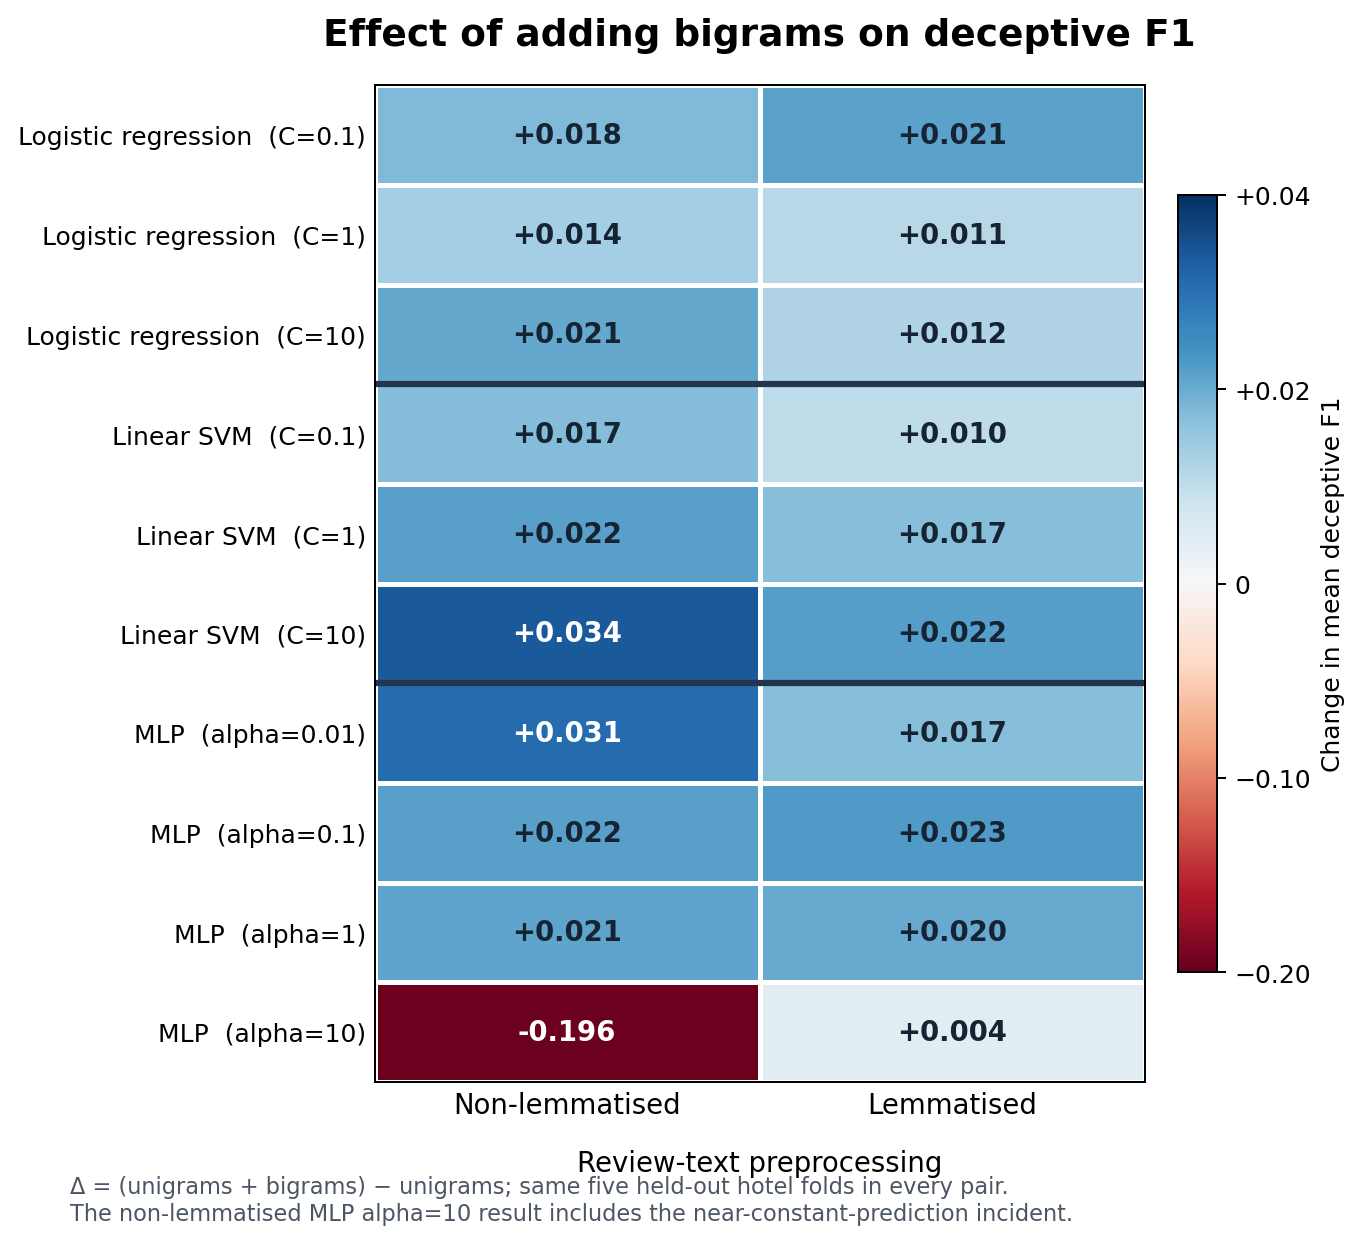

In [81]:
# Plot the mean paired change in deceptive F1 for every matched setting.
heatmap_data = (
    representation_comparison
    .set_index(["Model", "Setting", "Text"])["_mean_delta"]
    .unstack("Text")
    .reindex(setting_order)
    [["Non-lemmatised", "Lemmatised"]]
)
fig, ax = plt.subplots(figsize=(8.9, 7.1), dpi=180)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Use zero as the colour midpoint; numeric labels retain exact differences.
colour_scale = TwoSlopeNorm(vmin=-0.20, vcenter=0, vmax=0.04)
image = ax.imshow(
    heatmap_data.to_numpy(), cmap="RdBu", norm=colour_scale, aspect="auto"
)
ax.set_xticks([0, 1], ["Non-lemmatised", "Lemmatised"], fontsize=11)
ax.set_yticks(
    np.arange(len(setting_order)),
    [f"{model}  ({setting})" for model, setting in setting_order],
    fontsize=10,
)
ax.tick_params(axis="both", length=0)
ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(setting_order), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
for boundary in [2.5, 5.5]:
    ax.axhline(boundary, color="#23354d", linewidth=2.5)
for row in range(heatmap_data.shape[0]):
    for column in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[row, column]
        ax.text(
            column, row, f"{value:+.3f}", ha="center", va="center",
            fontsize=11, fontweight="bold",
            color="white" if value < -0.09 or value > 0.027 else "#152333",
        )
ax.set_title(
    "Effect of adding bigrams on deceptive F1", fontsize=15,
    fontweight="bold", pad=16,
)
ax.set_xlabel("Review-text preprocessing", fontsize=11, labelpad=12)
colourbar = fig.colorbar(image, ax=ax, shrink=0.78, pad=0.035)
colourbar.set_label("Change in mean deceptive F1", fontsize=10)
colourbar.set_ticks([-0.20, -0.10, 0, 0.02, 0.04])
colourbar.ax.set_yticklabels(["−0.20", "−0.10", "0", "+0.02", "+0.04"])
fig.text(
    0.12, 0.012,
    "Δ = (unigrams + bigrams) − unigrams; same five held-out hotel "
    "folds in every pair.\n"
    "The non-lemmatised MLP alpha=10 result includes the "
    "near-constant-prediction incident.",
    fontsize=9, color="#4b5563",
)
fig.subplots_adjust(left=0.31, right=0.90, top=0.90, bottom=0.12)
plt.show()

**Observations and representation choice**

Adding bigrams raised mean deceptive F1 in **19 of the 20 matched configurations**. It improved deceptive F1 in **93 of the 100 configuration-by-fold comparisons**. Those 100 comparisons reuse the same reviews across different model settings, so this count describes the consistency of the observed pattern; it is not 100 independent tests.

The clearest evidence for our selected model comes from the **non-lemmatised SVM at `C=10`**. Adding bigrams increased mean deceptive F1 by **0.034**, increased mean macro F1 by **0.031**, and improved deceptive F1 in **all five held-out folds**. Other SVM settings, logistic regression settings, and most MLP settings show gains in the same direction. The earlier full validation tables also show that the combined representation generally improved accuracy, precision, and recall.

The single negative mean result is the **non-lemmatised MLP at `alpha=10`**. Its combined representation produced near-constant predictions in two folds under strong regularisation, causing a large drop in its five-fold average. In the other three folds, adding bigrams still improved deceptive F1. This incident is important when judging that MLP setting, but it does not overturn the broader pattern across the matched experiments.

**We therefore select unigrams + bigrams as the text representation for the primary SVM.** Its final TF-IDF pipeline will use `ngram_range=(1, 2)`, fitting the vectoriser on the full training dataframe when we move to final training.

#### 5.2) Lemmatised vs Non-Lemmatised Reviews

We compare lemmatised and non-lemmatised reviews using the **same model, parameter setting, TF-IDF representation, and held-out hotel fold** in each pair. The heatmap shows the change in mean deceptive F1 for every setting. The two tables condense those differences by model family, separately for unigrams and unigrams + bigrams. A positive difference favours lemmatisation.

**Preparing matched preprocessing results**

We pair the existing fold results before calculating differences. This retains the hotel-grouped comparison while changing only whether the review text was lemmatised.

In [82]:
# Reuse the Section 5.1 fold results and pair preprocessing choices.
preprocessing_paired_results = representation_fold_results.pivot(
    index=["Model", "Setting", "Representation", "Fold"],
    columns="Text",
    values=["Deceptive F1", "Macro F1"],
)
assert len(preprocessing_paired_results) == 100
assert not preprocessing_paired_results.isna().any().any()

# Record the held-out-fold differences before summarising models.
preprocessing_fold_differences = (
    preprocessing_paired_results[("Deceptive F1", "Lemmatised")]
    - preprocessing_paired_results[("Deceptive F1", "Non-lemmatised")]
).rename("Delta F1").reset_index()

# Each setting compares the same model and hotel folds, changing text only.
preprocessing_setting_rows = []
for (model, setting, representation), folds in (
    preprocessing_paired_results.groupby(
        level=["Model", "Setting", "Representation"], sort=False
    )
):
    nonlemma_f1 = folds[("Deceptive F1", "Non-lemmatised")]
    lemma_f1 = folds[("Deceptive F1", "Lemmatised")]
    fold_delta = lemma_f1 - nonlemma_f1
    preprocessing_setting_rows.append({
        "Model": model,
        "Setting": setting,
        "Representation": representation,
        "Mean Δ deceptive F1": fold_delta.mean(),
        "SD Δ deceptive F1": fold_delta.std(ddof=1),
        "Folds favouring lemmatisation": int((fold_delta > 0).sum()),
    })
preprocessing_setting_comparison = pd.DataFrame(preprocessing_setting_rows)
assert len(preprocessing_setting_comparison) == 20


def format_signed_delta(value):
    # Values smaller than the displayed precision are approximately zero.
    return "≈0" if abs(value) < 0.0005 else f"{value:+.3f}"

# Summarise settings within each family, separately for both representations.
preprocessing_model_rows = []
for representation_name in representations:
    for model_name in ["Logistic regression", "Linear SVM", "MLP"]:
        settings = preprocessing_setting_comparison.loc[
            (preprocessing_setting_comparison["Representation"] == representation_name)
            & (preprocessing_setting_comparison["Model"] == model_name)
        ]
        fold_comparisons = preprocessing_fold_differences.loc[
            (preprocessing_fold_differences["Representation"] == representation_name)
            & (preprocessing_fold_differences["Model"] == model_name)
        ]
        changes = settings["Mean Δ deceptive F1"]
        preprocessing_model_rows.append({
            "Representation": representation_name,
            "Model": model_name,
            "Median setting Δ F1": format_signed_delta(changes.median()),
            "Setting Δ range": (
                f"{format_signed_delta(changes.min())} to "
                f"{format_signed_delta(changes.max())}"
            ),
            "Settings favouring lemmatisation": (
                f"{(changes > 0).sum()}/{len(settings)}"
            ),
            "Fold comparisons favouring lemmatisation": (
                f"{(fold_comparisons['Delta F1'] > 0).sum()}/"
                f"{len(fold_comparisons)}"
            ),
        })
preprocessing_model_comparison = pd.DataFrame(preprocessing_model_rows)
assert len(preprocessing_model_comparison) == 6

**Model-level comparison tables**

Each row summarises one model family across its tested regularisation settings. The **median setting Δ F1** describes the typical change in five-fold mean deceptive F1; the range keeps individual setting differences visible. The fold counts reuse the same reviews across settings and should be read as descriptive consistency, not independent tests.

In [83]:
# Show one model-level table for each TF-IDF representation.
for representation_name in representations:
    print(representation_name.capitalize())
    table = (
        preprocessing_model_comparison.loc[
            preprocessing_model_comparison["Representation"] == representation_name
        ]
        .drop(columns="Representation")
        .set_index("Model")
    )
    display(table)

Unigrams


,Median setting Δ F1,Setting Δ range,Settings favouring lemmatisation,Fold comparisons favouring lemmatisation
Model,,,,
Logistic regression,+0.002,-0.002 to +0.004,2/3,7/15
Linear SVM,≈0,-0.003 to +0.005,2/3,6/15
MLP,-0.006,-0.010 to +0.005,1/4,8/20


Unigrams + bigrams


,Median setting Δ F1,Setting Δ range,Settings favouring lemmatisation,Fold comparisons favouring lemmatisation
Model,,,,
Logistic regression,≈0,-0.010 to +0.008,1/3,7/15
Linear SVM,-0.007,-0.011 to -0.002,0/3,6/15
MLP,-0.009,-0.016 to +0.205,1/4,7/20


**Heatmap of lemmatisation effects**

The heatmap keeps all ten model and parameter settings visible for both text representations. Each number is the difference in five-fold mean deceptive F1: **lemmatised minus non-lemmatised**. Blue favours lemmatisation, red favours non-lemmatised text, and `≈0` denotes a difference smaller than 0.0005.

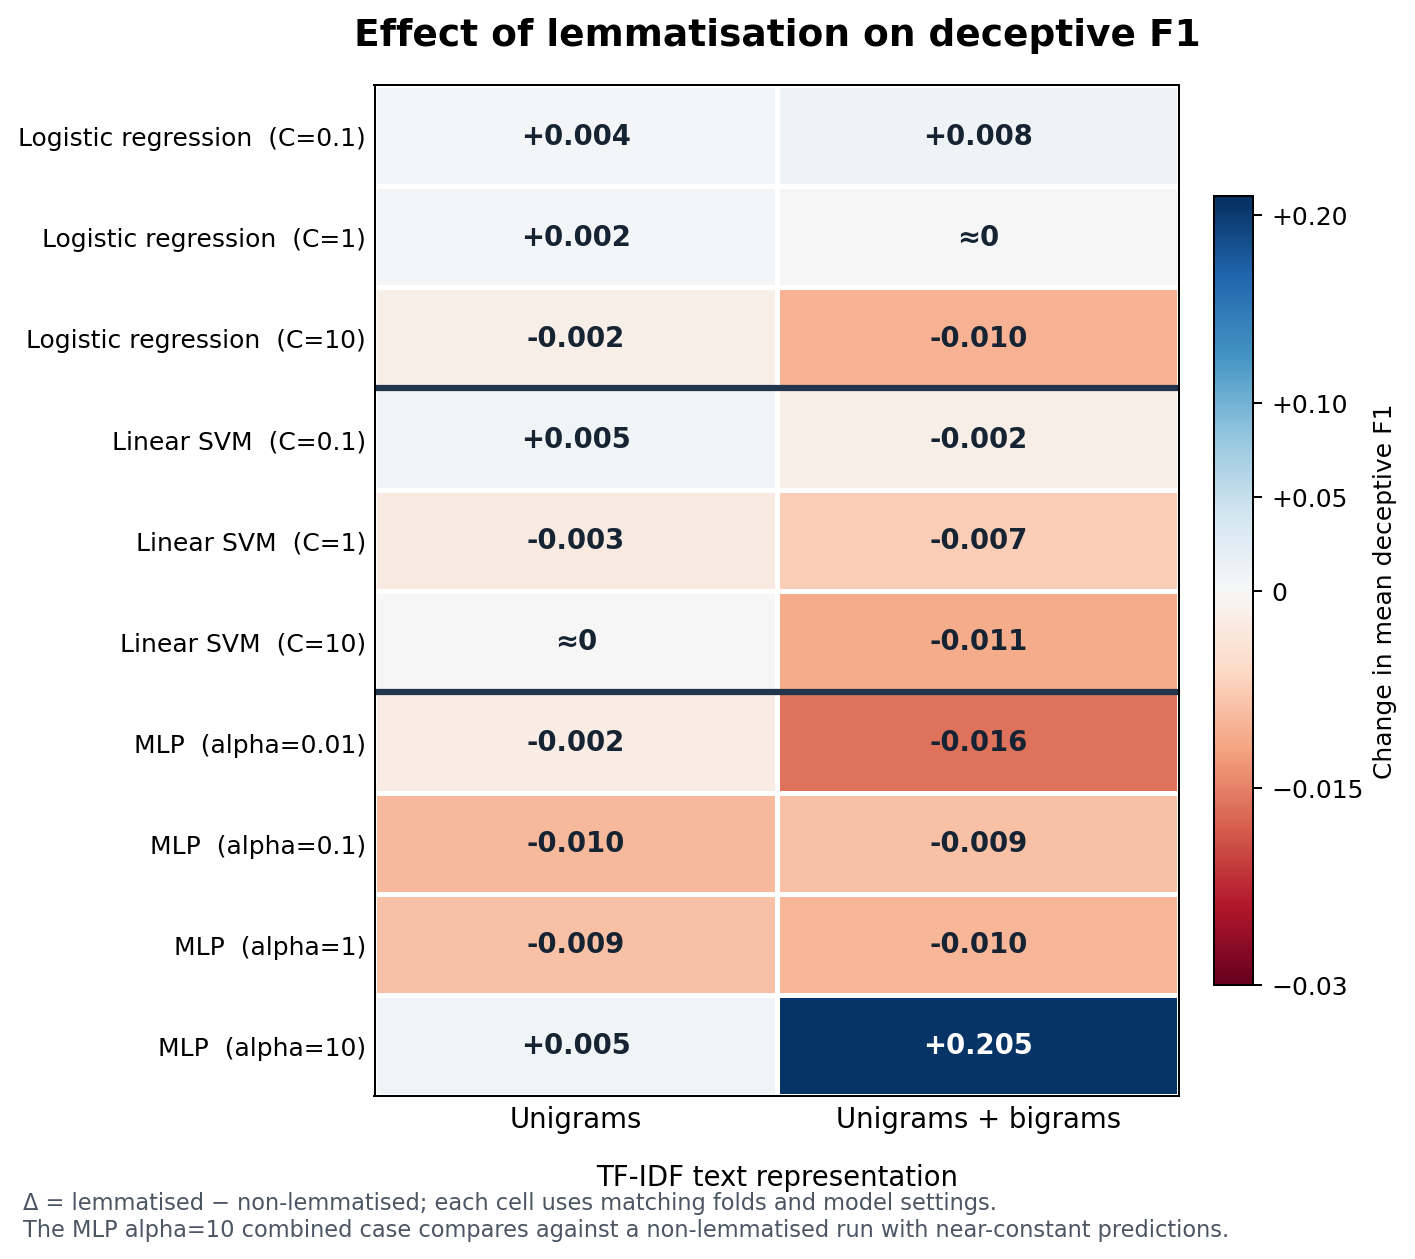

In [84]:
# Keep every tested parameter setting visible in the heatmap.
lemmatisation_heatmap_data = (
    preprocessing_setting_comparison
    .set_index(["Model", "Setting", "Representation"])["Mean Δ deceptive F1"]
    .unstack("Representation")
    .reindex(setting_order)
    [["unigrams", "unigrams + bigrams"]]
)

fig, ax = plt.subplots(figsize=(9.3, 7.2), dpi=180)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Centre colour at zero and retain visibility of the MLP alpha=10 outlier.
colour_scale = TwoSlopeNorm(vmin=-0.03, vcenter=0, vmax=0.21)
image = ax.imshow(
    lemmatisation_heatmap_data.to_numpy(),
    cmap="RdBu", norm=colour_scale, aspect="auto",
)
ax.set_xticks([0, 1], ["Unigrams", "Unigrams + bigrams"], fontsize=11)
ax.set_yticks(
    np.arange(len(setting_order)),
    [f"{model}  ({setting})" for model, setting in setting_order],
    fontsize=10,
)
ax.tick_params(axis="both", length=0)
ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(setting_order), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
for boundary in [2.5, 5.5]:
    ax.axhline(boundary, color="#23354d", linewidth=2.5)

# Add exact numeric labels, including ≈0 for tiny differences.
for row in range(lemmatisation_heatmap_data.shape[0]):
    for column in range(lemmatisation_heatmap_data.shape[1]):
        value = lemmatisation_heatmap_data.iloc[row, column]
        ax.text(
            column, row, format_signed_delta(value),
            ha="center", va="center", fontsize=11, fontweight="bold",
            color="white" if value > 0.10 or value < -0.018
            else "#152333",
        )
ax.set_title(
    "Effect of lemmatisation on deceptive F1",
    fontsize=15, fontweight="bold", pad=16,
)
ax.set_xlabel("TF-IDF text representation", fontsize=11, labelpad=12)
colourbar = fig.colorbar(image, ax=ax, shrink=0.78, pad=0.035)
colourbar.set_label("Change in mean deceptive F1", fontsize=10)
colourbar.set_ticks([-0.03, -0.015, 0, 0.05, 0.10, 0.20])
colourbar.ax.set_yticklabels(
    ["−0.03", "−0.015", "0", "+0.05", "+0.10", "+0.20"]
)
fig.text(
    0.10, 0.012,
    "Δ = lemmatised − non-lemmatised; each cell uses matching folds "
    "and model settings.\n"
    "The MLP alpha=10 combined case compares against a non-lemmatised "
    "run with near-constant predictions.",
    fontsize=9, color="#4b5563",
)
fig.subplots_adjust(left=0.31, right=0.90, top=0.90, bottom=0.12)
plt.show()

**Observations and preprocessing choice**

The heatmap shows little evidence that lemmatisation improves deceptive-review detection. Apart from one unusual MLP result, its positive changes in mean deceptive F1 are all below **0.008**. Several decreases are larger, reaching about **−0.016**. The unigram results are mixed and mostly close to zero; with unigrams + bigrams, the changes more often favour non-lemmatised text.

Lemmatisation improved mean deceptive F1 in **7 of 20 matched settings (35%)**, and in **41 of 100 setting-by-fold comparisons (41%)**. These comparisons reuse the same hotel folds across settings, so the counts describe the observed pattern rather than independent tests.

The model-level tables support that pattern. For unigrams, the median change across tested settings is **+0.002** for logistic regression, approximately zero for SVM, and **−0.006** for MLP. With unigrams + bigrams—the representation selected in Section 5.1—the medians are approximately zero, **−0.007**, and **−0.009**, respectively. These medians describe the tested settings; they are not estimates of statistical significance.

The large **+0.205** change for the combined-representation MLP at `alpha=10` needs separate treatment. Its non-lemmatised run made near-constant predictions in two folds, while its lemmatised run did not. That comparison reflects a failure of one particular model setting and does not establish a general benefit from lemmatisation.

The evidence most relevant to our primary model is consistent: **lemmatisation lowered mean deceptive F1 at all three tested SVM `C` settings when using unigrams + bigrams**. At `C=10`, non-lemmatised reviews reached **0.884 deceptive F1**, compared with **0.873** after lemmatisation. The differences are modest, but the tested results give us no performance reason to add this preprocessing step.

**We therefore select the non-lemmatised training dataframe for the primary SVM.** This choice follows the matched validation results and keeps the final text pipeline simpler. We will still check the selected pipeline on the reserved holdout after fitting it on the full training data.

#### 5.3) Comparing Model Families and Selecting the Primary Model

We have selected **non-lemmatised reviews represented by unigrams + bigrams** as the final text input. We therefore compare logistic regression, linear SVM, and MLP using their validation results on the **same five hotel-grouped folds** with that input. Each family is represented by its best *tested* setting for mean deceptive F1: logistic regression at C=10, linear SVM at C=10, and the notebook's single-hidden-layer MLP at alpha=0.01. The exploratory wider and deeper MLP runs are not included in this notebook comparison.

**How to read the visualisations**

The graph shows deceptive F1 for each held-out hotel fold. Each model's points use the same fold positions, so differences within a fold compare predictions on the same review group. The first table gives the exact displayed fold scores; the second reports the **mean ± sample standard deviation** of each validation metric across the five folds. These are cross-validation folds within the training data, not the reserved final validation dataframe.

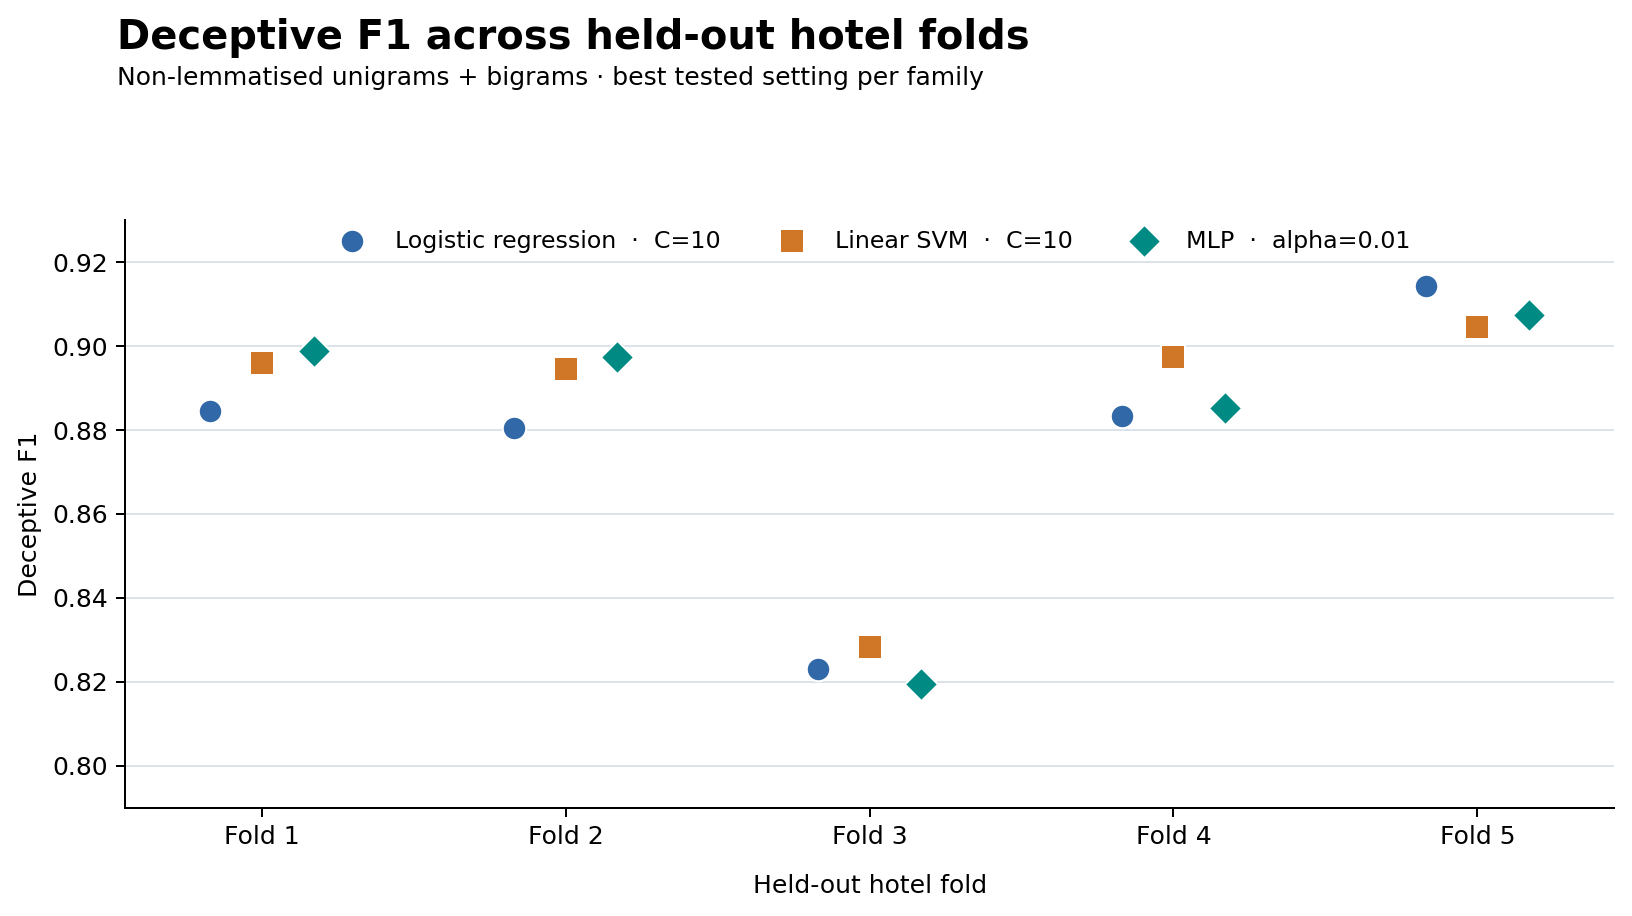

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select the best tested setting for each model family on the chosen text input.
family_specs = [
    ("Logistic regression", "C=10", logistic_text_results, "C", 10.0),
    ("Linear SVM", "C=10", svm_text_results, "C", 10.0),
    ("MLP", "alpha=0.01", mlp_text_results, "Alpha", 0.01),
]
family_model_order = [spec[0] for spec in family_specs]

family_fold_results = pd.concat(
    [
        results.loc[
            results["Text"].eq("Non-lemmatised")
            & results["Representation"].eq("unigrams + bigrams")
            & results[parameter].eq(value)
        ].assign(Model=model, Setting=label)[
            ["Model", "Setting", "Fold", *comparison_metrics]
        ]
        for model, label, results, parameter, value in family_specs
    ],
    ignore_index=True,
)

# Every family must be evaluated on the same five held-out hotel folds.
assert len(family_fold_results) == 15
assert family_fold_results.groupby("Model")["Fold"].nunique().eq(5).all()
assert set(family_fold_results["Fold"]) == {1, 2, 3, 4, 5}

# Offset points within each fold so close scores remain visible.
fig, ax = plt.subplots(figsize=(9.4, 5.35), dpi=180)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
plot_styles = [
    ("Logistic regression", "C=10", -0.17, "o", "#3169a8"),
    ("Linear SVM", "C=10", 0.00, "s", "#d07627"),
    ("MLP", "alpha=0.01", 0.17, "D", "#008a84"),
]
for model, setting, offset, marker, colour in plot_styles:
    model_folds = (
        family_fold_results.loc[family_fold_results["Model"] == model]
        .sort_values("Fold")
    )
    ax.scatter(
        model_folds["Fold"].to_numpy() + offset,
        model_folds["Deceptive F1"],
        s=88,
        marker=marker,
        color=colour,
        edgecolor="white",
        linewidth=0.8,
        label=f"{model}  ·  {setting}",
        zorder=3,
    )

ax.set_xlim(0.55, 5.45)
ax.set_ylim(0.79, 0.93)
ax.set_xticks(range(1, 6), [f"Fold {fold}" for fold in range(1, 6)])
ax.set_yticks(np.arange(0.80, 0.931, 0.02))
ax.set_xlabel("Held-out hotel fold", labelpad=10)
ax.set_ylabel("Deceptive F1")
ax.grid(axis="y", color="#dce2e9", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    fontsize=9.5,
)
fig.suptitle(
    "Deceptive F1 across held-out hotel folds",
    x=0.095, y=0.98, ha="left", fontsize=16, fontweight="semibold",
)
fig.text(
    0.095, 0.91,
    "Non-lemmatised unigrams + bigrams · best tested setting per family",
    ha="left", fontsize=10,
)
fig.subplots_adjust(left=0.10, right=0.98, top=0.77, bottom=0.16)
plt.show()

**Fold-level deceptive F1**

The table below shows the scores represented by the points in the graph.

In [ ]:
# Show the exact held-out deceptive F1 values used in the graph.
family_fold_table = (
    family_fold_results
    .pivot(index="Fold", columns="Model", values="Deceptive F1")
    .reindex(columns=family_model_order)
    .round(3)
)
display(family_fold_table)

Model,Logistic regression,Linear SVM,MLP
Fold,,,
1,0.884,0.896,0.899
2,0.880,0.895,0.897
3,0.823,0.828,0.819
4,0.883,0.897,0.885
5,0.914,0.904,0.907


**Average validation metrics**

Each entry below is the mean ± sample standard deviation across the five hotel-grouped validation folds.

In [ ]:
# Summarise all validation metrics for the three selected family settings.
family_metric_summary = (
    family_fold_results
    .groupby("Model")[comparison_metrics]
    .agg(["mean", "std"])
    .reindex(family_model_order)
)
family_metric_table = pd.DataFrame({
    metric: (
        family_metric_summary[(metric, "mean")].map("{:.3f}".format)
        + " ± "
        + family_metric_summary[(metric, "std")].map("{:.3f}".format)
    )
    for metric in comparison_metrics
})
family_metric_table.insert(
    0, "Setting", ["C=10", "C=10", "alpha=0.01"]
)
display(family_metric_table)

,Setting,Accuracy,Precision,Recall,Deceptive F1,Macro F1
Model,,,,,,
Logistic regression,C=10,0.879 ± 0.029,0.888 ± 0.030,0.868 ± 0.058,0.877 ± 0.033,0.879 ± 0.029
Linear SVM,C=10,0.886 ± 0.028,0.898 ± 0.027,0.872 ± 0.055,0.884 ± 0.031,0.886 ± 0.028
MLP,alpha=0.01,0.884 ± 0.032,0.899 ± 0.027,0.866 ± 0.055,0.882 ± 0.036,0.884 ± 0.032


**Observations and model choice**

The fold-by-fold graph shows that **logistic regression trails SVM on Folds 1–4**, then achieves the highest deceptive F1 on Fold 5. MLP leads on Folds 1 and 2, while SVM leads on Folds 3 and 4. Logistic regression also edges MLP on Fold 3. No model family wins on every hotel group, although SVM and MLP are generally close to one another.

**Fold 3 is the most difficult for all three families.** Its deceptive F1 is 0.823 for logistic regression, 0.828 for SVM, and 0.819 for MLP. Fold 3 contains reviews from the Ambassador, Hyatt, and Sofitel hotels, with 120 truthful and 120 deceptive reviews. Its lower performance is therefore not explained by class imbalance. Deceptive recall is lower here than on most other folds, suggesting that the models miss more deceptive reviews in this hotel group. Individual error inspection would be needed to explain why.

The summary table favours SVM: it has the highest mean accuracy (0.886), deceptive recall (0.872), deceptive F1 (0.884), and macro F1 (0.886). MLP is close at 0.882 deceptive F1 and 0.884 macro F1, with precision higher by only 0.001. Logistic regression remains competitive at 0.877 deceptive F1. The differences between model means are small relative to fold-to-fold variation. SVM has the smallest deceptive-F1 standard deviation (0.031), but all three settings show broadly similar variation, so this comparison does not establish a large reliability advantage for either SVM or MLP over logistic regression.

**SVM and MLP are the strongest candidates from the tested model families.** The MLP's nonlinear boundary does not deliver a clear improvement over the linear SVM on these sparse TF-IDF features. Its additional flexibility brings architecture and initialisation choices without an observed gain in the selected comparison. Scikit-learn notes that MLP training is non-convex and can depend on the starting weights; its linear SVM supports sparse input and suits high-dimensional text classification. See the [MLP guide](https://scikit-learn.org/stable/modules/neural_networks_supervised.html), [SVM guide](https://scikit-learn.org/stable/modules/svm), and [sparse text classification example](https://scikit-learn.org/stable/auto_examples/text/plot_document_classification_20newsgroups.html).

**We select the linear SVM at C=10 as the primary model**, using non-lemmatised unigrams + bigrams. It has the strongest observed five-fold summary and a simpler structure than the MLP. The selected pipeline can now fit its vectoriser and classifier on the full training dataframe before being checked once on the reserved validation dataframe.

### 6. Conclusion

This notebook used five hotel-grouped cross-validation folds to compare logistic regression, linear SVM, and a single-hidden-layer MLP across different regularisation settings and text representations. **Unigrams + bigrams** generally improved prediction over unigrams alone, while lemmatisation provided no consistent benefit. The SVM performed at least as well as the more complex MLP across the strongest tested configurations and showed greater consistency across its parameter trials.

We therefore select **linear SVM with non-lemmatised TF-IDF unigrams + bigrams** as Review Buster’s primary prediction pipeline. Its strongest tested configuration achieved a mean **deceptive F1 of 0.884** and **macro F1 of 0.886** across the five validation folds. These scores guide our selection; they are not the final test results.

The next stage is to finalise any remaining SVM settings using training data, then fit a fresh TF-IDF vectoriser and SVM on **all 1,277 training reviews from 16 hotels**. We will evaluate that fitted pipeline on the **319 reviews from four hotels reserved for final testing**. This held-out test set is separate from the five cross-validation folds and has not been used to select the pipeline.